# Team-6 전체 파이프라인 통합 노트북

이 노트북은 **Google Colab에서 위에서부터 모두 실행**하는 상황을 기준으로 정리했다.
기본 실행은 GitHub 저장소에 포함된 중간/가공/PCA CSV를 사용하므로 Kaggle 토큰이나
Google Drive가 필요하지 않다.

## 권장 실행 방법

1. Colab 메뉴에서 `런타임 > 런타임 유형 변경`을 열고 GPU(T4)를 선택한다.
2. 아래 환경 설정 셀의 기본값을 유지한다.
3. `런타임 > 모두 실행`을 선택한다.

기본값:

- `RUN_RAW_PIPELINE = False`: Yelp 원본 JSON 다운로드와 도시별 샘플 재생성을 건너뛴다.
- `RUN_EMBEDDING = False`: 시간이 오래 걸리는 RoBERTa 임베딩 재생성을 건너뛴다.

두 옵션을 `True`로 바꾸면 해당 단계를 재생성할 수 있다. 원본 재생성에는
Kaggle API 토큰(`kaggle.json`)이 필요하고, 임베딩 재생성에는 GPU 사용을 권장한다.
재생성 결과와 분석 결과는 런타임 메모리 및 노트북 화면에서만 사용한다.


# 1단계 EDA 및 도시별 샘플링

Yelp 원본 JSON에서 분석 대상 도시의 레스토랑 리뷰를 추출하고 감성 라벨을 만든다.
결과는 파일로 저장하지 않고 런타임 메모리에서 이후 분석에 사용한다.


In [1]:
from pathlib import Path
import os
import subprocess
import sys


def running_in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ModuleNotFoundError:
        return False


IN_COLAB = running_in_colab()
REPO_URL = "https://github.com/2026-1st/Team-6.git"

# Colab 폼에서 필요할 때만 True로 변경한다.
RUN_RAW_PIPELINE = False  # @param {type:"boolean"}
RUN_EMBEDDING = False  # @param {type:"boolean"}

if IN_COLAB:
    PROJECT_ROOT = Path("/content/Team-6")
    if not (PROJECT_ROOT / ".git").exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", REPO_URL, str(PROJECT_ROOT)],
            check=True,
        )
else:
    current = Path.cwd().resolve()
    PROJECT_ROOT = next(
        (
            path
            for path in [current, *current.parents]
            if (path / "data").exists() and (path / "notebooks").exists()
        ),
        None,
    )
    if PROJECT_ROOT is None:
        raise FileNotFoundError("data/와 notebooks/가 있는 저장소 루트를 찾을 수 없다.")

os.chdir(PROJECT_ROOT)

# Colab 기본 이미지에 없는 핵심 패키지만 설치한다.
if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "catboost>=1.2,<2",
            "shap>=0.46,<1",
            "wordcloud>=1.9,<2",
            "kaggle>=1.6,<2",
        ],
        check=True,
    )

INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
EMBEDDING_DIR = PROJECT_ROOT / "data" / "embeddings"

# 재생성 결과는 파일로 쓰지 않고 런타임 메모리에만 보관한다.
sampled_datasets = {}
pca_datasets = {}

print(f"실행 환경: {'Google Colab' if IN_COLAB else 'Local'}")
print(f"프로젝트 루트: {PROJECT_ROOT}")
print(f"원본 데이터 재생성: {RUN_RAW_PIPELINE}")
print(f"RoBERTa 임베딩 재생성: {RUN_EMBEDDING}")


실행 환경: Google Colab
프로젝트 루트: /content/Team-6
원본 데이터 재생성: False
RoBERTa 임베딩 재생성: False


## 1. 실행 환경 및 데이터 준비

이 구간은 Yelp 원본 데이터에서 도시별 15,000건 샘플을 **다시 만드는 선택 단계**이다.
기본 실행에서는 `RUN_RAW_PIPELINE=False`이므로 아래 원본 데이터 셀을 건너뛰고,
저장소의 `data/interim/` 파일을 사용한다.

재생성이 필요한 경우에만 첫 설정 셀에서 `RUN_RAW_PIPELINE=True`로 변경한다.
그러면 `kaggle.json` 업로드 창이 열리고, 약 10GB의 압축 파일 다운로드 및 해제가 진행된다.
Colab 무료 런타임의 디스크 여유 공간과 실행 시간을 먼저 확인한다.


In [2]:
if not RUN_RAW_PIPELINE:
    print("원본 Yelp 다운로드를 건너뛴다. 저장소의 data/interim CSV를 사용한다.")
else:
    from google.colab import files

    print("Kaggle API 토큰인 kaggle.json을 업로드한다.")
    uploaded = files.upload()
    if "kaggle.json" not in uploaded:
        raise FileNotFoundError("kaggle.json이 업로드되지 않았다.")

    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/kaggle.json
    !chmod 600 ~/.kaggle/kaggle.json
    !kaggle datasets download -d yelp-dataset/yelp-dataset -p /content
    !rm -rf /content/yelp_data
    !unzip -q /content/yelp-dataset.zip -d /content/yelp_data
    print("Yelp 데이터 다운로드 및 압축 해제 완료")


원본 Yelp 다운로드를 건너뛴다. 저장소의 data/interim CSV를 사용한다.


In [3]:
if not RUN_RAW_PIPELINE:
    print('원본 데이터 재생성 단계이므로 건너뛴다.')
else:
    import pandas as pd

    # 비즈니스 데이터 불러오기
    biz_path = '/content/yelp_data/yelp_academic_dataset_business.json'
    biz_df = pd.read_json(biz_path, lines=True)

    # 'Restaurants' 카테고리 필터링 (결측치 처리 포함)
    biz_df = biz_df[biz_df['categories'].fillna('').str.contains('Restaurants')]

    # 필라델피아 도시 필터링
    target_city = 'Philadelphia'
    biz_city = biz_df[biz_df['city'] == target_city]

    # 추출할 식당들의 고유 ID 리스트 확보
    target_biz_ids = set(biz_city['business_id'].tolist()) # 검색 속도를 위해 set으로 변환
    print(f"{target_city} 내 대상 식당 개수: {len(target_biz_ids)}개")


원본 데이터 재생성 단계이므로 건너뛴다.


## 2. Philadelphia 샘플 생성

비즈니스 JSON에서 Philadelphia 레스토랑 `business_id`를 먼저 추출한 뒤, 리뷰 JSON을 청크 단위로 읽어 해당 식당 리뷰만 남긴다.


In [4]:
if not RUN_RAW_PIPELINE:
    print('원본 데이터 재생성 단계이므로 건너뛴다.')
else:
    review_path = '/content/yelp_data/yelp_academic_dataset_review.json'
    chunk_size = 100000
    review_chunks = []

    print("리뷰 데이터 청크 필터링 시작... (약 3~5분 소요 예상)")

    # 10만 줄씩 잘라서 읽기
    for chunk in pd.read_json(review_path, lines=True, chunksize=chunk_size):
        # 대상 식당 ID에 해당하는 리뷰만 남기기
        filtered_chunk = chunk[chunk['business_id'].isin(target_biz_ids)]
        review_chunks.append(filtered_chunk)

    # 모아둔 조각들을 하나의 데이터프레임으로 병합
    review_subset = pd.concat(review_chunks, ignore_index=True)
    print(f"필터링된 총 리뷰 개수: {len(review_subset)}개")


원본 데이터 재생성 단계이므로 건너뛴다.


In [5]:
if not RUN_RAW_PIPELINE:
    print('원본 데이터 재생성 단계이므로 건너뛴다.')
else:
    # 1. 3점 리뷰(중립) 제거
    review_subset = review_subset[review_subset['stars'] != 3]

    # 2. 4~5점은 1(긍정), 1~2점은 0(부정)으로 매핑
    review_subset['is_positive'] = review_subset['stars'].apply(lambda x: 1 if x > 3 else 0)

    # 3. 15,000개 무작위 샘플링 (10,000개 이상 요건 충족)
    final_dataset = review_subset.sample(n=15000, random_state=42)

    print("최종 샘플링 데이터 크기:", final_dataset.shape)
    display(final_dataset.head(3))


원본 데이터 재생성 단계이므로 건너뛴다.


In [6]:
if RUN_RAW_PIPELINE:
    sampled_datasets["philly"] = final_dataset.copy()
    print("Philadelphia 샘플을 메모리에 보관했다.")


In [7]:
if not RUN_RAW_PIPELINE:
    print('원본 데이터 재생성 단계이므로 건너뛴다.')
else:
    import pandas as pd

    # 비즈니스 데이터 불러오기
    biz_path = '/content/yelp_data/yelp_academic_dataset_business.json'
    biz_df = pd.read_json(biz_path, lines=True)

    # 'Restaurants' 카테고리 필터링 (결측치 처리 포함)
    biz_df = biz_df[biz_df['categories'].fillna('').str.contains('Restaurants')]

    # 투손(Tucson) 도시 필터링 적용
    target_city = 'Tucson'
    biz_city = biz_df[biz_df['city'] == target_city]

    # 추출할 식당들의 고유 ID 리스트 확보
    target_biz_ids = set(biz_city['business_id'].tolist())
    print(f"{target_city} 내 대상 식당 개수: {len(target_biz_ids)}개")


원본 데이터 재생성 단계이므로 건너뛴다.


In [8]:
if not RUN_RAW_PIPELINE:
    print('원본 데이터 재생성 단계이므로 건너뛴다.')
else:
    review_path = '/content/yelp_data/yelp_academic_dataset_review.json'
    chunk_size = 100000
    review_chunks = []

    print(f"{target_city} 리뷰 데이터 청크 필터링 시작... (약 3~5분 소요 예상)")

    # 10만 줄씩 잘라서 읽기
    for chunk in pd.read_json(review_path, lines=True, chunksize=chunk_size):
        # 대상 식당 ID에 해당하는 리뷰만 남기기
        filtered_chunk = chunk[chunk['business_id'].isin(target_biz_ids)]
        review_chunks.append(filtered_chunk)

    # 모아둔 조각들을 하나의 데이터프레임으로 병합
    review_subset = pd.concat(review_chunks, ignore_index=True)
    print(f"필터링된 총 리뷰 개수: {len(review_subset)}개")


원본 데이터 재생성 단계이므로 건너뛴다.


## 3. Tucson 샘플 생성

동일한 기준으로 Tucson 레스토랑 리뷰를 필터링하고 3점 중립 리뷰를 제거한 뒤 15,000건을 샘플링한다.


In [9]:
if not RUN_RAW_PIPELINE:
    print('원본 데이터 재생성 단계이므로 건너뛴다.')
else:
    # 1. 3점 리뷰(중립) 제거
    review_subset = review_subset[review_subset['stars'] != 3]

    # 2. 4~5점은 1(긍정), 1~2점은 0(부정)으로 매핑
    review_subset['is_positive'] = review_subset['stars'].apply(lambda x: 1 if x > 3 else 0)

    # 3. 15,000개 무작위 샘플링
    final_dataset = review_subset.sample(n=15000, random_state=42)

    print("최종 샘플링 데이터 크기:", final_dataset.shape)

    display(final_dataset.head(3))


원본 데이터 재생성 단계이므로 건너뛴다.


In [10]:
if RUN_RAW_PIPELINE:
    sampled_datasets["tucson"] = final_dataset.copy()
    print("Tucson 샘플을 메모리에 보관했다.")


In [11]:
if not RUN_RAW_PIPELINE:
    print('원본 데이터 재생성 단계이므로 건너뛴다.')
else:
    import pandas as pd

    # 비즈니스 데이터 불러오기
    biz_path = '/content/yelp_data/yelp_academic_dataset_business.json'
    biz_df = pd.read_json(biz_path, lines=True)

    # 'Restaurants' 카테고리 필터링 (결측치 처리 포함)
    biz_df = biz_df[biz_df['categories'].fillna('').str.contains('Restaurants')]

    # 뉴올리언스(New Orleans) 도시 필터링 적용
    target_city = 'New Orleans'
    biz_city = biz_df[biz_df['city'] == target_city]

    # 추출할 식당들의 고유 ID 리스트 확보
    target_biz_ids = set(biz_city['business_id'].tolist())
    print(f"{target_city} 내 대상 식당 개수: {len(target_biz_ids)}개")


원본 데이터 재생성 단계이므로 건너뛴다.


In [12]:
if not RUN_RAW_PIPELINE:
    print('원본 데이터 재생성 단계이므로 건너뛴다.')
else:
    review_path = '/content/yelp_data/yelp_academic_dataset_review.json'
    chunk_size = 100000
    review_chunks = []

    print(f"{target_city} 리뷰 데이터 청크 필터링 시작...")

    # 10만 줄씩 잘라서 읽기
    for chunk in pd.read_json(review_path, lines=True, chunksize=chunk_size):
        # 대상 식당 ID에 해당하는 리뷰만 남기기
        filtered_chunk = chunk[chunk['business_id'].isin(target_biz_ids)]
        review_chunks.append(filtered_chunk)

    # 모아둔 조각들을 하나의 데이터프레임으로 병합
    review_subset = pd.concat(review_chunks, ignore_index=True)
    print(f"필터링된 총 리뷰 개수: {len(review_subset)}개")


원본 데이터 재생성 단계이므로 건너뛴다.


In [13]:
if not RUN_RAW_PIPELINE:
    print('원본 데이터 재생성 단계이므로 건너뛴다.')
else:
    # 1. 3점 리뷰(중립) 제거
    review_subset = review_subset[review_subset['stars'] != 3]

    # 2. 4~5점은 1(긍정), 1~2점은 0(부정)으로 매핑
    review_subset['is_positive'] = review_subset['stars'].apply(lambda x: 1 if x > 3 else 0)

    # 3. 15,000개 무작위 샘플링
    final_dataset = review_subset.sample(n=15000, random_state=42)

    print("최종 샘플링 데이터 크기:", final_dataset.shape)
    display(final_dataset.head(3))


원본 데이터 재생성 단계이므로 건너뛴다.


## 4. New Orleans 샘플 생성

New Orleans도 같은 파이프라인을 적용하여 도시별 비교가 가능한 입력 CSV를 만든다.


In [14]:
if RUN_RAW_PIPELINE:
    sampled_datasets["new_orleans"] = final_dataset.copy()
    print("New Orleans 샘플을 메모리에 보관했다.")


In [15]:
# Colab에서 한글 그래프 제목을 표시하기 위한 글꼴 설정
if IN_COLAB:
    !apt-get -qq update
    !apt-get -qq install -y fonts-nanum

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
if Path(font_path).exists():
    fm.fontManager.addfont(font_path)
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


## 5. 샘플 EDA 및 시각화

각 도시 샘플의 타깃 분포, 텍스트 길이, 워드클라우드를 화면에 표시한다.


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

# 앞 환경 설정 셀에서 등록한 NanumGothic을 그대로 사용한다.
plt.rcParams['axes.unicode_minus'] = False

BASE_STOPWORDS = {
    "food", "place", "restaurant", "good", "great", "time", "one",
    "really", "even", "came", "went", "got", "make", "will", "go",
    "ordered", "us", "back", "much", "well"
}


def load_city_sample(city_slug, input_file):
    if city_slug in sampled_datasets:
        return sampled_datasets[city_slug].copy()
    return pd.read_csv(INTERIM_DIR / input_file)


def plot_city_eda(city_name, city_slug, input_file, extra_stopwords=None):
    df = load_city_sample(city_slug, input_file)
    df['text_length'] = df['text'].astype(str).apply(len)

    summary_table = df.groupby('is_positive').agg(
        review_count=('review_id', 'count'),
        avg_stars=('stars', 'mean'),
        avg_text_length=('text_length', 'mean'),
    ).reset_index()
    display(summary_table)

    plt.figure(figsize=(8, 6))
    ax = sns.countplot(data=df, x='is_positive', hue='is_positive', palette=['#ff9999', '#66b3ff'], legend=False)
    plt.title(f'{city_name} 리뷰 만족도 분포', fontsize=16, fontweight='bold')
    plt.xlabel('만족도 (0: 불만족, 1: 만족)', fontsize=12)
    plt.ylabel('리뷰 개수', fontsize=12)
    for patch in ax.patches:
        height = patch.get_height()
        ax.text(patch.get_x() + patch.get_width() / 2, height + 50, f'{int(height):,}', ha='center', size=12)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='is_positive', y='text_length', hue='is_positive', palette=['#ff9999', '#66b3ff'], legend=False)
    plt.title(f'{city_name} 만족도별 리뷰 텍스트 길이', fontsize=16, fontweight='bold')
    plt.xlabel('만족도 (0: 불만족, 1: 만족)', fontsize=12)
    plt.ylabel('리뷰 길이 (글자 수)', fontsize=12)
    plt.ylim(0, df['text_length'].quantile(0.95))
    plt.tight_layout()
    plt.show()

    pos_text = " ".join(df.loc[df['is_positive'] == 1, 'text'].astype(str))
    neg_text = " ".join(df.loc[df['is_positive'] == 0, 'text'].astype(str))
    custom_stopwords = set(STOPWORDS) | BASE_STOPWORDS | set(extra_stopwords or [])

    wc_pos = WordCloud(width=600, height=400, background_color='white', colormap='Greens', stopwords=custom_stopwords, max_words=100).generate(pos_text)
    wc_neg = WordCloud(width=600, height=400, background_color='white', colormap='Reds', stopwords=custom_stopwords, max_words=100).generate(neg_text)

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    axes[0].imshow(wc_pos, interpolation='bilinear')
    axes[0].set_title('만족(긍정) 핵심 키워드', fontsize=18, fontweight='bold')
    axes[0].axis('off')
    axes[1].imshow(wc_neg, interpolation='bilinear')
    axes[1].set_title('불만족(부정) 위기 키워드', fontsize=18, fontweight='bold')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()


### 필라델피아 EDA

샘플의 타깃 불균형, 텍스트 길이, 긍정/부정 키워드를 확인한다.


#### 차트 읽는 법

먼저 긍정·부정 리뷰 수로 클래스 불균형을 확인한다. 텍스트 길이 그래프는 두 집단의 작성 패턴 차이를, 워드클라우드는 반복적으로 등장하는 표현을 빠르게 살펴보기 위한 그림이다.


,is_positive,review_count,avg_stars,avg_text_length
0,0,3120,1.471795,684.950000
1,1,11880,4.587795,548.794444


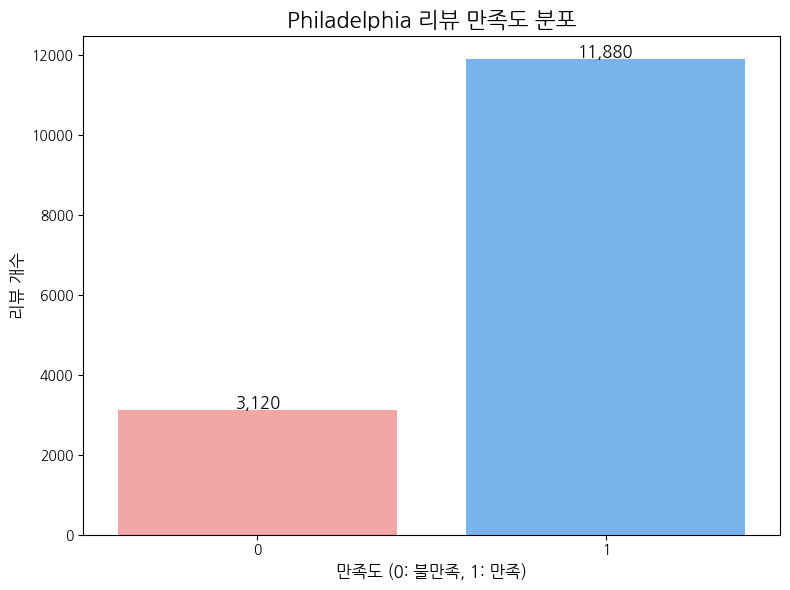

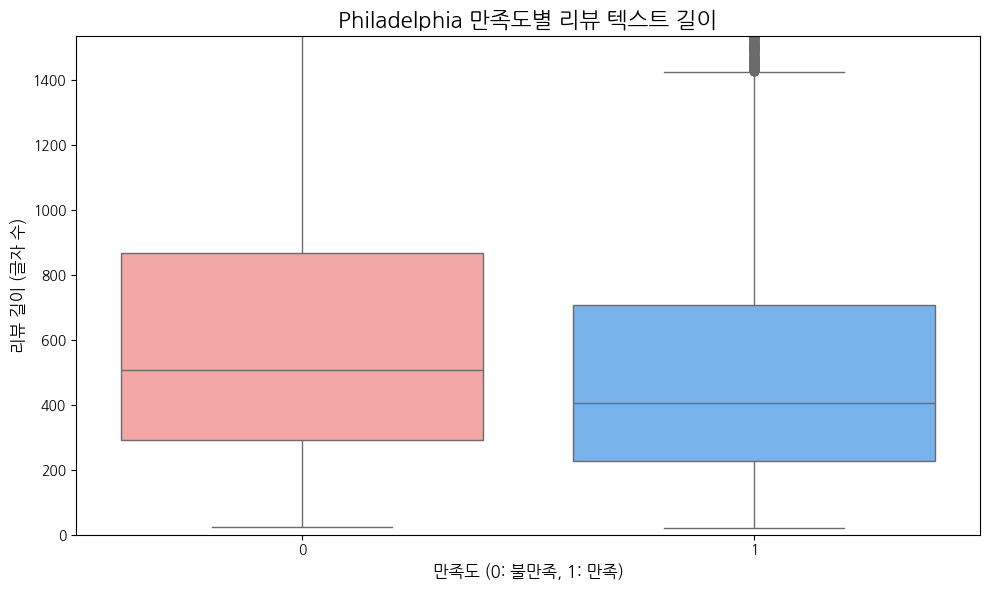

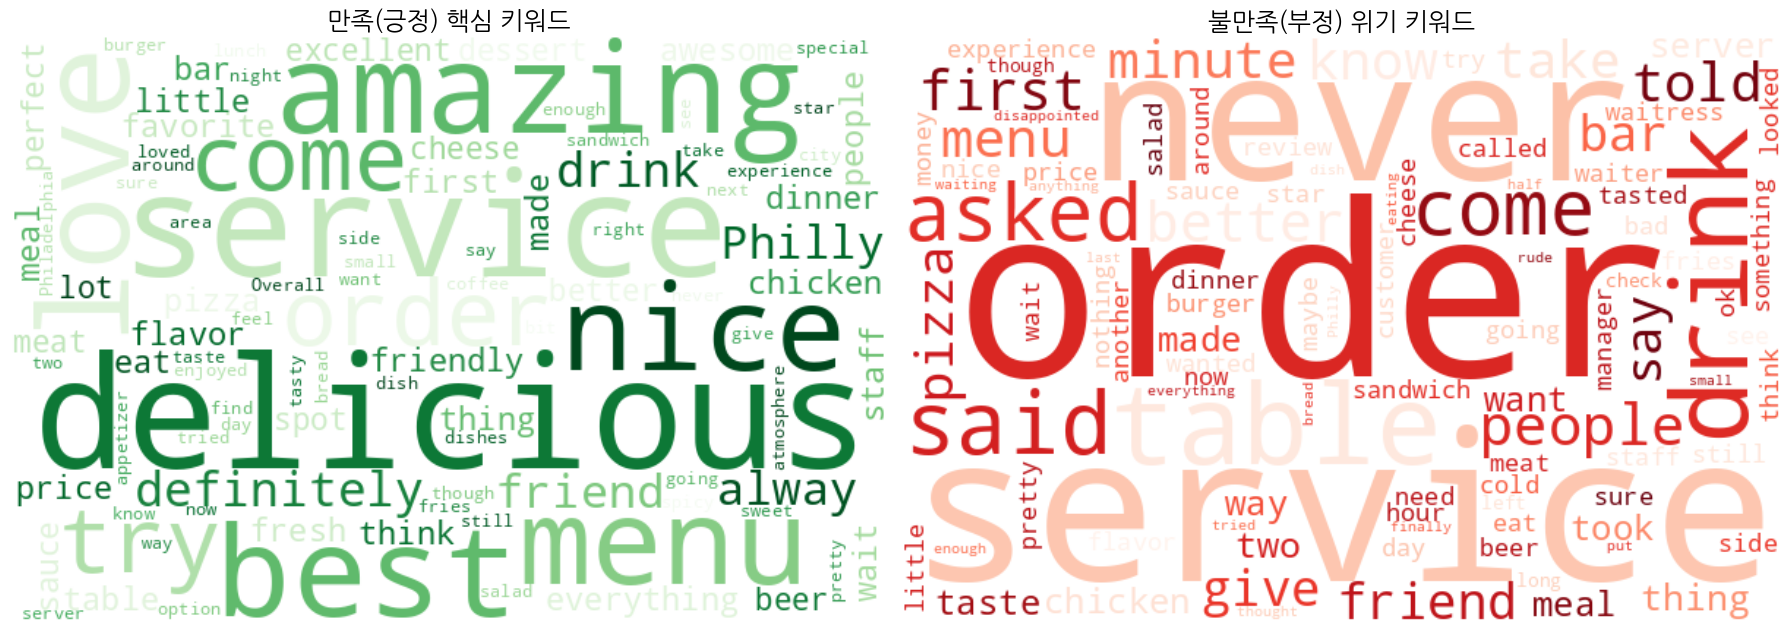

In [17]:
plot_city_eda('Philadelphia', 'philly', 'yelp_subset_philly_15k.csv')

### 투손 EDA

도시명이 워드클라우드에 과도하게 반영되지 않도록 Tucson 관련 단어를 stopword에 추가한다.


#### 차트 읽는 법

Philadelphia와 같은 기준으로 분포와 리뷰 길이를 비교한다. 워드클라우드에서는 도시명 자체를 제외해 실제 경험과 관련된 단어가 더 잘 드러나도록 했다.


,is_positive,review_count,avg_stars,avg_text_length
0,0,3831,1.397285,663.922997
1,1,11169,4.657087,472.203152


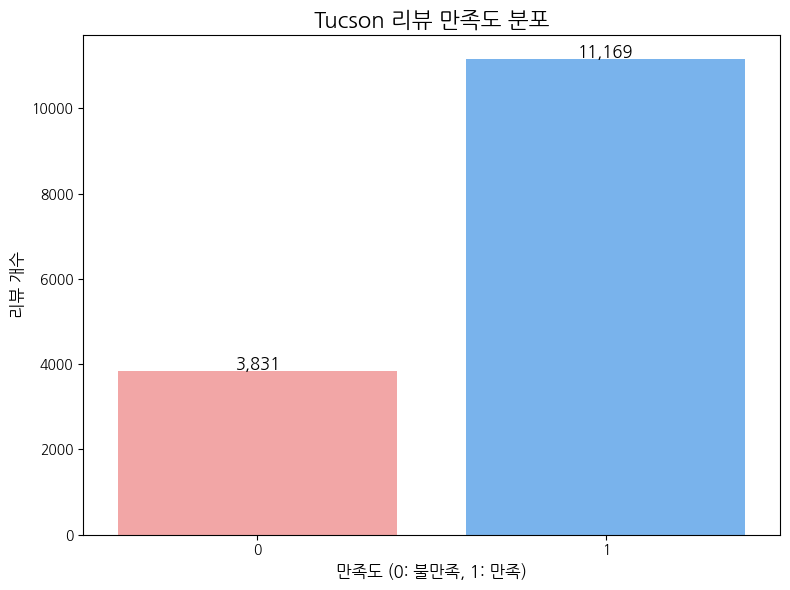

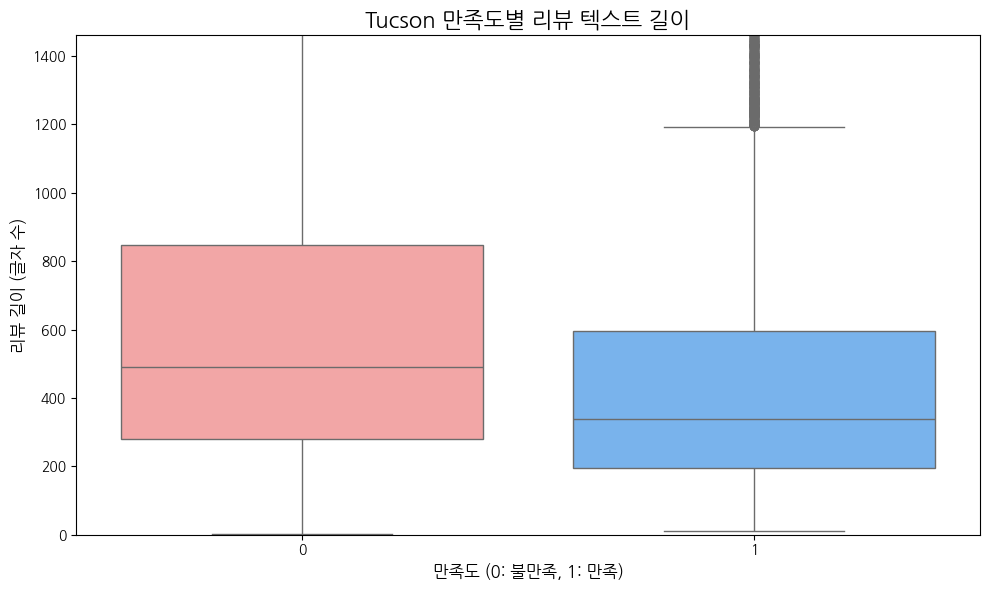

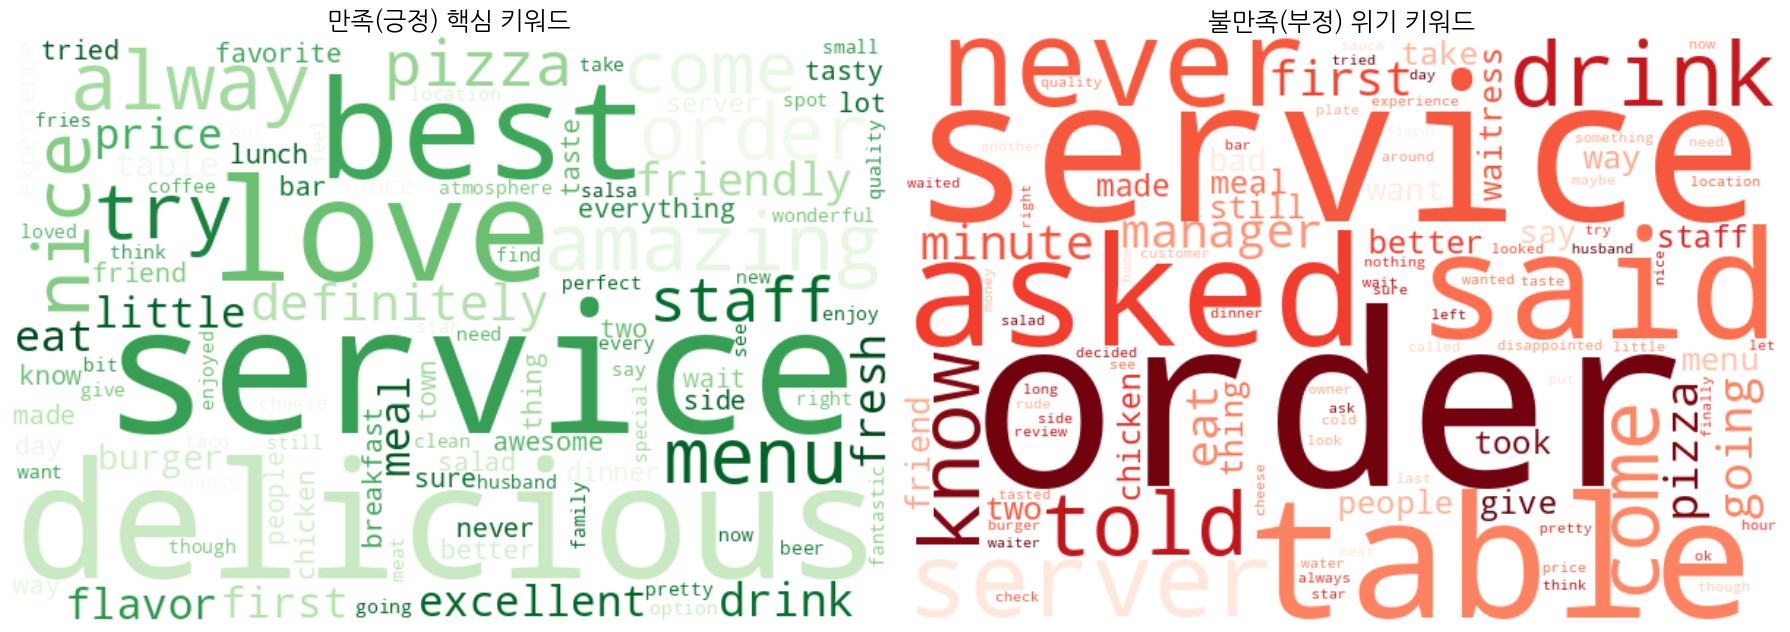

In [18]:
plot_city_eda('Tucson', 'tucson', 'yelp_subset_tucson_15k.csv', extra_stopwords=['Tucson', 'tucson'])

### 뉴올리언스 EDA

New Orleans/NOLA 표현이 핵심 키워드를 가리지 않도록 도시명 관련 단어를 제외한다.


#### 차트 읽는 법

긍정 비율뿐 아니라 부정 리뷰의 규모도 함께 보는 것이 중요하다. 워드클라우드는 빈도가 높은 표현을 보여 주지만, 단어의 문맥이나 원인을 확정하는 결과는 아니라는 점에 유의한다.


,is_positive,review_count,avg_stars,avg_text_length
0,0,2743,1.448779,685.543930
1,1,12257,4.657094,487.410623


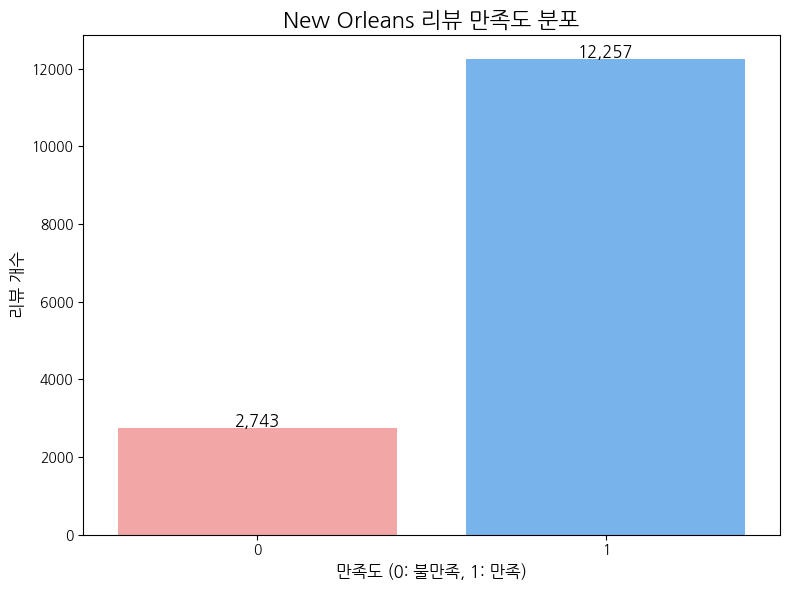

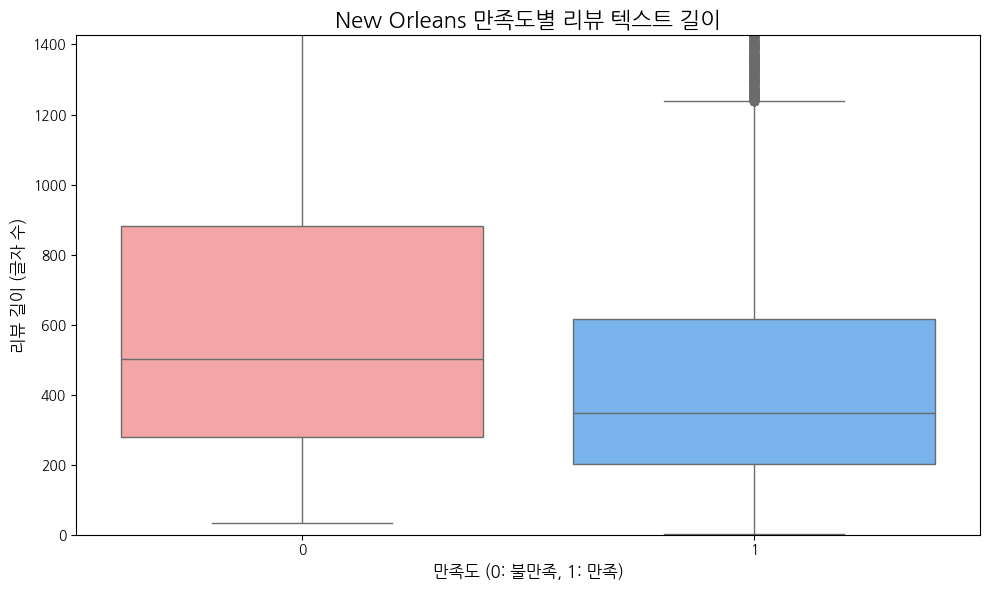

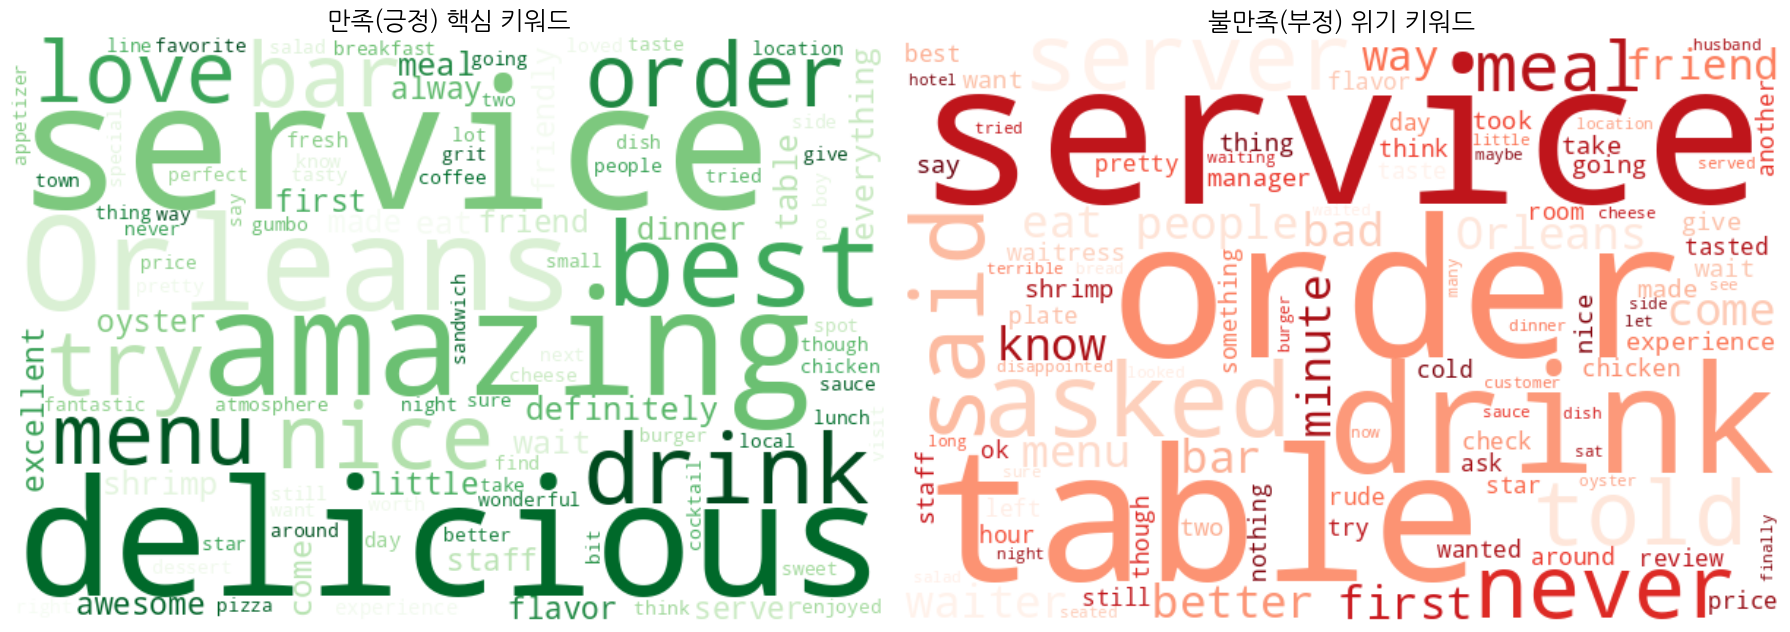

In [19]:
plot_city_eda('New Orleans', 'new_orleans', 'yelp_subset_new_orleans_15k.csv', extra_stopwords=['New Orlean', 'New Orleans', 'NOLA', 'nola', 'new orleans', 'New', 'Orlean'])

---

# 2-1단계. 사업장 위치 CSV 생성

원본 사업장 JSON에서 위치 정보만 추출해 `data/interim/business_location.csv`를 만든다.

원본 노트북: `notebooks/02_feature_engineering/Create_Business_Location_CSV.ipynb`


# 사업장 위치 정보 추출

원본 사업장 JSON에서 위치 정보를 추출해 메모리에서 피처 엔지니어링에 사용한다.
기본 실행에서는 저장소의 기존 `business_location.csv`를 입력으로 읽는다.


## 1. 경로 설정

사업장 위치 정보 추출도 원본 Yelp JSON이 필요한 선택 단계이다. 기본 실행에서는 저장소에 포함된
`data/interim/business_location.csv`를 그대로 사용한다. `RUN_RAW_PIPELINE=True`일 때만
`/content/yelp_data/yelp_academic_dataset_business.json`에서 위치 정보를 메모리로 추출한다.


In [20]:
BUSINESS_JSON_PATH = Path("/content/yelp_data/yelp_academic_dataset_business.json")
BUSINESS_LOCATION_PATH = INTERIM_DIR / "business_location.csv"

print(f"사업장 JSON 경로: {BUSINESS_JSON_PATH}")
print(f"기존 위치 CSV 경로: {BUSINESS_LOCATION_PATH}")


사업장 JSON 경로: /content/yelp_data/yelp_academic_dataset_business.json
기존 위치 CSV 경로: /content/Team-6/data/interim/business_location.csv


## 2. 원본 JSON 확인

In [21]:
if RUN_RAW_PIPELINE:
    if not BUSINESS_JSON_PATH.exists():
        raise FileNotFoundError(
            "사업장 JSON을 찾을 수 없다. 앞의 Kaggle 다운로드 셀을 먼저 실행한다.\n"
            f"경로: {BUSINESS_JSON_PATH}"
        )
    print(f"사업장 JSON 확인 완료: {BUSINESS_JSON_PATH.stat().st_size / 1024**2:.2f} MB")
else:
    print(f"기존 위치 CSV 사용: {BUSINESS_LOCATION_PATH}")


기존 위치 CSV 사용: /content/Team-6/data/interim/business_location.csv


## 3. 위치 정보 추출

In [22]:
if not RUN_RAW_PIPELINE:
    print('기존 business_location.csv를 사용하므로 추출을 건너뛴다.')
else:
    USE_COLUMNS = ['business_id', 'city', 'state', 'latitude', 'longitude']

    business_df = pd.read_json(BUSINESS_JSON_PATH, lines=True)
    business_location = business_df[USE_COLUMNS].copy()

    business_location = business_location.dropna(subset=['business_id'])
    business_location = business_location.drop_duplicates('business_id')

    print('사업장 위치 데이터 크기:', business_location.shape)
    display(business_location.head())


기존 business_location.csv를 사용하므로 추출을 건너뛴다.


## 4. 결과 확인


In [23]:
if RUN_RAW_PIPELINE:
    print("사업장 위치 데이터 크기:", business_location.shape)
    print("결측치 개수:")
    print(business_location.isnull().sum())
    display(business_location.head())
else:
    print("저장소에 포함된 business_location.csv를 사용한다.")


저장소에 포함된 business_location.csv를 사용한다.


---

# 2-2단계. 피처 엔지니어링

도시별 샘플 CSV에 텍스트, 날짜, 유저, 식당, 위치 기반 파생변수를 추가한다.

원본 노트북: `notebooks/02_feature_engineering/Feature_Engineering.ipynb`


# 피처 엔지니어링

도시별 샘플에 텍스트, 날짜, 유저, 식당, 위치 기반 파생변수를 추가한다.
생성 결과는 `feature_datasets`에 보관한다.


## 1. 환경 설정 및 경로 확인

첫 환경 설정 셀에서 결정한 `PROJECT_ROOT`를 그대로 사용한다. Colab 기본 실행에서는
`/content/Team-6`이며, 저장소의 `data/interim/` 파일을 입력으로 읽는다.
생성한 피처는 파일로 쓰지 않고 `feature_datasets`에 보관한다.


In [24]:
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

INPUT_DIR = INTERIM_DIR

BUSINESS_LOCATION_CSV_CANDIDATES = [
    INTERIM_DIR / "business_location.csv",
]
BUSINESS_JSON_CANDIDATES = [
    Path("/content/yelp_data/yelp_academic_dataset_business.json"),
    PROJECT_ROOT / "data" / "raw" / "yelp_academic_dataset_business.json",
]

CITY_CONFIGS = [
    {"city": "Philadelphia", "city_slug": "philly", "input_file": "yelp_subset_philly_15k.csv"},
    {"city": "Tucson", "city_slug": "tucson", "input_file": "yelp_subset_tucson_15k.csv"},
    {"city": "New Orleans", "city_slug": "new_orleans", "input_file": "yelp_subset_new_orleans_15k.csv"},
]

KMEANS_CLUSTERS = 5
RANDOM_STATE = 42
DRIVE_PROJECT_ROOT = PROJECT_ROOT

print(f"입력 폴더: {INPUT_DIR}")


입력 폴더: /content/Team-6/data/interim


## 2. 입력 파일 확인

In [25]:
def check_input_files(city_configs=CITY_CONFIGS):
    missing_files = []
    for config in city_configs:
        input_path = INPUT_DIR / config['input_file']
        if not input_path.exists():
            missing_files.append(input_path)

    if missing_files:
        missing_text = '\n'.join(str(path) for path in missing_files)
        raise FileNotFoundError(f'입력 CSV 파일을 찾을 수 없다:\n{missing_text}')

    print('입력 CSV 파일 확인 완료')


check_input_files()

입력 CSV 파일 확인 완료


## 3. 공통 함수 정의

In [26]:
def add_text_features(df):
    df = df.copy()
    df['text'] = df['text'].fillna('').astype(str)

    df['text_length'] = df['text'].str.len()
    df['word_count'] = df['text'].str.split().str.len()
    df['sentence_count'] = df['text'].str.count(r'[.!?]+').clip(lower=1)
    df['avg_word_length'] = df['text_length'] / df['word_count'].clip(lower=1)
    df['uppercase_ratio'] = df['text'].apply(
        lambda text: sum(1 for char in text if char.isupper()) / max(len(text), 1)
    )
    df['exclamation_count'] = df['text'].str.count('!')
    df['question_count'] = df['text'].str.count(r'\?')
    df['engagement_sum'] = df[['useful', 'funny', 'cool']].fillna(0).sum(axis=1)
    return df


def add_date_features(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

    df['review_year'] = df['date'].dt.year
    df['review_month'] = df['date'].dt.month
    df['review_dayofweek'] = df['date'].dt.dayofweek
    df['is_weekend'] = df['review_dayofweek'].isin([5, 6]).astype(int)
    return df


def add_user_features(df):
    df = df.copy()
    user_stats = df.groupby('user_id')['stars'].agg(
        user_review_count='count',
        user_avg_stars='mean'
    ).reset_index()

    df = df.merge(user_stats, on='user_id', how='left')
    df['user_star_deviation'] = df['stars'] - df['user_avg_stars']
    return df


def add_business_features(df):
    df = df.copy()
    business_stats = df.groupby('business_id')['stars'].agg(
        business_review_count='count',
        business_avg_stars='mean'
    ).reset_index()

    df = df.merge(business_stats, on='business_id', how='left')
    df['business_star_deviation'] = df['stars'] - df['business_avg_stars']
    return df


def find_business_location_csv_path():
    for path in BUSINESS_LOCATION_CSV_CANDIDATES:
        if path.exists():
            print(f'사업장 위치 CSV 확인: {path}')
            return path

    matches = list(DRIVE_PROJECT_ROOT.rglob('business_location.csv'))
    if matches:
        detected_path = matches[0]
        print(f'사업장 위치 CSV 확인: {detected_path}')
        return detected_path

    return None


def find_business_json_path():
    for path in BUSINESS_JSON_CANDIDATES:
        if path.exists():
            print(f'사업장 JSON 확인: {path}')
            return path

    matches = list(DRIVE_PROJECT_ROOT.rglob('yelp_academic_dataset_business.json'))
    if matches:
        detected_path = matches[0]
        print(f'사업장 JSON 확인: {detected_path}')
        return detected_path

    return None


def load_business_locations(business_ids):
    location_csv_path = find_business_location_csv_path()
    if location_csv_path is not None:
        location_df = pd.read_csv(location_csv_path)
        return location_df.loc[
            location_df['business_id'].isin(business_ids),
            ['business_id', 'latitude', 'longitude']
        ].drop_duplicates('business_id')

    business_json_path = find_business_json_path()
    if business_json_path is None:
        print('사업장 위치 CSV 또는 business.json을 찾지 못해 위치 기반 피처 생성을 건너뛴다.')
        print('필요 파일명: business_location.csv 또는 yelp_academic_dataset_business.json')
        print(f'검색한 경로: {DRIVE_PROJECT_ROOT}')
        return None

    print(f'사업장 위치 정보 불러오기: {business_json_path}')
    biz_df = pd.read_json(business_json_path, lines=True)
    location_df = biz_df.loc[
        biz_df['business_id'].isin(business_ids),
        ['business_id', 'latitude', 'longitude']
    ].drop_duplicates('business_id')
    return location_df


def add_location_features(df, location_df):
    df = df.copy()
    if location_df is None:
        df['latitude'] = np.nan
        df['longitude'] = np.nan
        return df

    return df.merge(location_df, on='business_id', how='left')


def add_kmeans_cluster(df, n_clusters=KMEANS_CLUSTERS, random_state=RANDOM_STATE):
    df = df.copy()
    df['business_cluster'] = np.nan

    coords = df[['latitude', 'longitude']].dropna()
    if coords.empty:
        print('사용 가능한 좌표가 없어 K-Means 클러스터링을 건너뛴다.')
        return df

    unique_count = coords.drop_duplicates().shape[0]
    cluster_count = min(n_clusters, unique_count)
    if cluster_count < 2:
        print('고유 좌표 수가 부족해 K-Means 클러스터링을 건너뛴다.')
        return df

    scaler = StandardScaler()
    coords_scaled = scaler.fit_transform(coords)

    kmeans = KMeans(n_clusters=cluster_count, random_state=random_state, n_init='auto')
    df.loc[coords.index, 'business_cluster'] = kmeans.fit_predict(coords_scaled)
    df['business_cluster'] = df['business_cluster'].astype('Int64')
    return df


def add_all_features(df, location_df):
    df = add_text_features(df)
    df = add_date_features(df)
    df = add_user_features(df)
    df = add_business_features(df)
    df = add_location_features(df, location_df)
    df = add_kmeans_cluster(df)
    return df


def summarize_features(df):
    print('데이터 크기:', df.shape)
    print('\n타깃 분포:')
    print(df['is_positive'].value_counts(dropna=False))
    print('\n결측치가 많은 컬럼:')
    print(df.isnull().sum().sort_values(ascending=False).head(15))

## 4. 위치 정보 로드

`business.json`이 `/content/yelp_data` 또는 Drive의 `Team-6/data`에 있으면 위도/경도를 병합하고 K-Means 클러스터를 생성한다. 파일이 없으면 위치 기반 피처만 건너뛴다.

In [27]:
all_business_ids = set()
for config in CITY_CONFIGS:
    city_slug = config['city_slug']
    if city_slug in sampled_datasets:
        temp_df = sampled_datasets[city_slug][['business_id']]
    else:
        temp_df = pd.read_csv(INPUT_DIR / config['input_file'], usecols=['business_id'])
    all_business_ids.update(temp_df['business_id'].dropna().unique())

if RUN_RAW_PIPELINE and 'business_location' in globals():
    location_df = business_location.loc[
        business_location['business_id'].isin(all_business_ids),
        ['business_id', 'latitude', 'longitude'],
    ].drop_duplicates('business_id')
else:
    location_df = load_business_locations(all_business_ids)
if location_df is not None:
    print('위치 정보 행 수:', location_df.shape[0])
    display(location_df.head())

사업장 위치 CSV 확인: /content/Team-6/data/interim/business_location.csv
위치 정보 행 수: 7012


,business_id,latitude,longitude
3,MTSW4McQd7CbVtyjqoe9mw,39.955505,-75.155564
15,MUTTqe8uqyMdBl186RmNeA,39.953949,-75.143226
19,ROeacJQwBeh05Rqg7F6TCg,39.943223,-75.162568
28,QdN72BWoyFypdGJhhI5r7g,39.939825,-75.157447
31,Mjboz24M9NlBeiOJKLEd_Q,40.022466,-75.218314


## 5. 도시별 피처 생성


In [28]:
feature_datasets = {}

for config in CITY_CONFIGS:
    city = config['city']
    city_slug = config['city_slug']

    print(f'\n[{city}] 피처 생성 시작')
    if city_slug in sampled_datasets:
        df = sampled_datasets[city_slug].copy()
    else:
        df = pd.read_csv(INPUT_DIR / config['input_file'])
    print('원본 데이터 크기:', df.shape)

    feature_df = add_all_features(df, location_df)
    summarize_features(feature_df)
    feature_datasets[city] = feature_df

print('\n전체 피처 생성 완료')



[Philadelphia] 피처 생성 시작
원본 데이터 크기: (15000, 10)
데이터 크기: (15000, 31)

타깃 분포:
is_positive
1    11880
0     3120
Name: count, dtype: int64

결측치가 많은 컬럼:
review_id          0
user_id            0
business_id        0
stars              0
useful             0
funny              0
cool               0
text               0
date               0
is_positive        0
text_length        0
word_count         0
sentence_count     0
avg_word_length    0
uppercase_ratio    0
dtype: int64

[Tucson] 피처 생성 시작
원본 데이터 크기: (15000, 10)
데이터 크기: (15000, 31)

타깃 분포:
is_positive
1    11169
0     3831
Name: count, dtype: int64

결측치가 많은 컬럼:
review_id          0
user_id            0
business_id        0
stars              0
useful             0
funny              0
cool               0
text               0
date               0
is_positive        0
text_length        0
word_count         0
sentence_count     0
avg_word_length    0
uppercase_ratio    0
dtype: int64

[New Orleans] 피처 생성 시작
원본 데이터 크기: (15000, 10)
데이터 크

## 6. 결과 확인

In [29]:
for city, feature_df in feature_datasets.items():
    print(f"{city}: {feature_df.shape}")

sample_city = CITY_CONFIGS[0]['city']
display(feature_datasets[sample_city].head())


Philadelphia: (15000, 31)
Tucson: (15000, 31)
New Orleans: (15000, 31)


,review_id,user_id,business_id,stars,useful,funny,cool,text,date,is_positive,...,is_weekend,user_review_count,user_avg_stars,user_star_deviation,business_review_count,business_avg_stars,business_star_deviation,latitude,longitude,business_cluster
0,yrgcQRzGdvODnmPgGzsLPg,8Oj4m1xxNoI1P_1mek9fQQ,QWqKTWQ2OiDgo3dzNkpung,5,3,0,1,After hearing rumors of delicious Soft Tofu pl...,2010-08-18 18:20:37,1,...,0,6,3.666667,1.333333,13,4.538462,0.461538,40.052064,-75.127394,4
1,QxtMgdD8Pz0w7XAUIPi3lg,KXYRjdlgg-Gw7mwF22ZAJg,0h4Oo6W8mG4HEYQzZRkoOA,4,0,0,1,Tasty new location in a plaza full of vietname...,2017-05-29 20:31:01,1,...,0,2,4.000000,0.000000,2,4.000000,0.000000,40.034890,-75.100337,4
2,gl3C_xngo9dUwJVz0lC2sw,gOAvWocRyGbKvUaitVy8fQ,nP4LqTcK1USiw5WnbOjW7A,5,0,0,0,"i ADMIT, I COME OFTEN: because all the food h...",2010-12-11 02:27:30,1,...,1,12,4.750000,0.250000,1,5.000000,0.000000,39.956716,-75.210034,0
3,PKHKI7US_xXiNH4ml6k5GA,-xw19I8BbBP35H2sCN2uRQ,WYel6hMEEPNwzVUlVBacbw,4,1,0,1,I really like this place. The salads are excel...,2017-03-26 17:49:40,1,...,1,1,4.000000,0.000000,11,3.454545,0.545455,39.950723,-75.167501,0
4,QcbZk6Wj8Rh8cZZeA7OtVA,jugISJYY36jq2Bse8dKugg,mlrYh-m3Zlqp9CTeSvdOsQ,5,0,0,0,Teriyaki and spicy chicken bowls were bombbbbb...,2016-08-25 00:32:01,1,...,0,1,5.000000,0.000000,3,4.666667,0.333333,39.948994,-75.159035,2


## 7. 위치 기반 리뷰 빈도 히트맵

메모리의 피처 데이터로 도시별 히트맵을 만들고 노트북 화면에 표시한다.


#### 히트맵 해석

색이 진한 곳은 리뷰가 많이 모인 식당이나 상권을 의미한다. 이는 만족도가 높은 지역이 아니라, 리뷰 활동이 집중된 위치를 보여 주는 분포도이다.


In [30]:
import folium
from folium.plugins import HeatMap
from IPython.display import display


def build_review_location_counts(feature_df):
    required_columns = {'business_id', 'latitude', 'longitude'}
    missing_columns = required_columns - set(feature_df.columns)
    if missing_columns:
        raise KeyError(f'히트맵 생성에 필요한 컬럼이 없다: {sorted(missing_columns)}')

    location_df = feature_df.dropna(subset=['business_id', 'latitude', 'longitude']).copy()
    location_df['latitude'] = pd.to_numeric(location_df['latitude'], errors='coerce')
    location_df['longitude'] = pd.to_numeric(location_df['longitude'], errors='coerce')
    location_df = location_df.dropna(subset=['latitude', 'longitude'])

    return (
        location_df
        .groupby(['business_id', 'latitude', 'longitude'])
        .size()
        .reset_index(name='review_count')
        .sort_values('review_count', ascending=False)
    )


def create_review_heatmap(city, feature_df):
    location_counts = build_review_location_counts(feature_df)
    if location_counts.empty:
        print(f'[{city}] 사용할 수 있는 위치 데이터가 없어 히트맵을 건너뛴다.')
        return None

    heat_data = location_counts[['latitude', 'longitude', 'review_count']].values.tolist()
    center = [location_counts['latitude'].mean(), location_counts['longitude'].mean()]

    review_map = folium.Map(location=center, zoom_start=12, tiles='CartoDB positron')
    HeatMap(
        heat_data,
        radius=18,
        blur=22,
        min_opacity=0.25,
        max_zoom=15,
        name='리뷰 빈도 히트맵',
    ).add_to(review_map)

    for row in location_counts.head(30).itertuples(index=False):
        folium.CircleMarker(
            location=[row.latitude, row.longitude],
            radius=max(4, min(14, row.review_count ** 0.5)),
            color='#2f4858',
            fill=True,
            fill_opacity=0.65,
            popup=f'리뷰 수: {row.review_count}<br>business_id: {row.business_id}',
        ).add_to(review_map)

    folium.LayerControl().add_to(review_map)
    display(location_counts.head(10))
    return review_map


review_heatmaps = {
    city: create_review_heatmap(city, feature_df)
    for city, feature_df in feature_datasets.items()
}

last_map = next((m for m in reversed(list(review_heatmaps.values())) if m is not None), None)
if last_map is not None:
    display(last_map)


,business_id,latitude,longitude,review_count
3364,ytynqOUb3hjKeJfRj5Tshw,39.953341,-75.158855,123
1416,PP3BBaVxZLcJU54uP_wL6Q,39.933201,-75.159266,94
550,9PZxjhTIU7OgPIzuGi89Ew,39.949702,-75.161770,83
395,6ajnOk0GcY9xbb5Ocaw8Gw,39.950007,-75.162158,82
2511,j-qtdD55OLfSqfsWuQTDJg,39.949172,-75.170727,81
2167,ctHjyadbDQAtUFfkcAFEHw,39.946261,-75.145135,76
69,0RuvlgTnKFbX3IK0ZOOocA,39.948123,-75.162463,73
521,8pqdJjefYq-a9IBSJJmKwA,39.951004,-75.170636,64
601,AGlh4ZDv6jnoiYfz7At9mw,39.955399,-75.156727,62
1053,IkY2ticzHEn4QFn8hQLSWg,39.933837,-75.158814,59


,business_id,latitude,longitude,review_count
936,UCMSWPqzXjd7QHq7v8PJjQ,32.255528,-110.943492,146
699,LZzDvgfpkd4nI3E4L9wF1w,32.225713,-110.974624,94
877,Rv8bW3pkzpi5dZu5ckbgtA,32.271774,-110.953235,80
1008,WSx9-iYYyST_umny9sJBFg,32.324564,-110.975876,80
1739,tV46IhCfHbsx_af-pMupiw,32.223068,-110.969506,77
1376,hyeo7JQr5uLp-St1MibYAA,32.219643,-110.843324,73
1406,j8feOxyJqlIJWOi8su2qzw,32.236675,-110.865028,71
1962,zZ01WQlcpI1_n806WKV3bA,32.250763,-110.934132,70
61,14QP5lOdrTAVVCDDuHIAUg,32.221522,-110.934106,65
1865,wj8XtPyuREj8_0GQz3LZ6w,32.321518,-110.930607,61


,business_id,latitude,longitude,review_count
972,ac1AeYqs8Z4_e2X5M3if2A,29.956231,-90.067563,241
945,_ab50qdWOk0DdB6XOrBitw,29.954273,-90.068965,226
932,_C7QiQQc47AOEv4PE3Kong,29.928735,-90.084196,191
1314,oBNrLz4EDhiscSlbOl8uAw,29.951025,-90.067394,173
783,VQcCL9PiNL_wkGf-uF3fjg,29.956473,-90.066386,159
1167,iSRTaT9WngzB8JJ2YKJUig,29.949057,-90.067049,145
1112,gTC8IQ_i8zXytWSly3Ttvg,29.942236,-90.067098,142
426,GBTPC53ZrG1ZBY3DT8Mbcw,29.950742,-90.070416,138
787,VaO-VW3e1kARkU9bP1E7Fw,29.954680,-90.068945,124
192,6a4gLLFSgr-Q6CZXDLzBGQ,29.942280,-90.067268,118


---

# 3단계. RoBERTa 임베딩 및 PCA

이 단계는 3개 도시의 45,000개 리뷰를 `distilroberta-base`로 임베딩하므로 가장 오래 걸린다.
기본 실행에서는 `RUN_EMBEDDING=False`로 건너뛰고 저장소의 `data/embeddings/*_pca_32.csv`를
사용한다. 재생성하려면 GPU 런타임을 선택한 뒤 첫 설정 셀에서 옵션을 `True`로 바꾼다.


## [3-1단계] 자연어 텍스트 임베딩 추출 (RoBERTa)

**1. 작업 목표**
머신러닝 모델(CatBoost)은 영어 문장을 그대로 읽을 수 없다. 따라서 사전 학습된 거대 언어 모델(LLM)을 활용하여, 리뷰 텍스트 문장의 전반적인 맥락과 감정을 컴퓨터가 이해할 수 있는 **768차원의 숫자 벡터** 로 번역하는 작업을 수행한다.

**2. 세부 설정**
* **사용 모델:** `distilroberta-base` (RoBERTa 모델의 경량화 버전으로, 성능은 유지하면서 연산 속도가 훨씬 빠르다.)
* **하드웨어:** T4 GPU (연산 속도 최적화)
* **배치 처리:** GPU 메모리 초과(OOM) 에러를 방지하기 위해 15,000개의 데이터를 32개씩 쪼개어 순차적으로 임베딩을 추출한다.

**3. 예상 결과물**
* `15,000(리뷰 개수) x 768(문맥 벡터)` 크기의 거대한 숫자 행렬 도출

## 메모리 기반 재생성

재생성한 PCA 결과는 `pca_datasets`에 보관한다. 각 PCA 데이터는 같은 도시의 리뷰와
행 순서가 같아야 한다. PCA는 도시별로 별도 적합하므로 도시 간 축 번호를 직접 비교하지 않는다.


## 임베딩 및 PCA 일괄 생성

아래 셀은 세 도시를 순서대로 처리하고 결과를 `pca_datasets`에 보관한다.
`RUN_EMBEDDING=False`이면 저장소의 기존 PCA CSV를 입력으로 사용한다.


In [31]:
if RUN_EMBEDDING:
    import numpy as np
    import pandas as pd
    import torch
    from sklearn.decomposition import PCA
    from tqdm.auto import tqdm
    from transformers import AutoModel, AutoTokenizer

    if not torch.cuda.is_available():
        raise RuntimeError("임베딩 재생성에는 GPU 런타임을 권장한다. Colab 런타임 유형을 확인한다.")

    torch.manual_seed(42)
    np.random.seed(42)

    model_name = "distilroberta-base"
    device = torch.device("cuda")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device)
    model.eval()

    embedding_jobs = {
        "philly": "yelp_subset_philly_15k.csv",
        "tucson": "yelp_subset_tucson_15k.csv",
        "new_orleans": "yelp_subset_new_orleans_15k.csv",
    }

    for city_slug, input_file in embedding_jobs.items():
        input_path = INTERIM_DIR / input_file
        texts = pd.read_csv(input_path, usecols=["text"])["text"].fillna("").astype(str).tolist()
        batches = []

        with torch.inference_mode():
            for start in tqdm(range(0, len(texts), 32), desc=f"[{city_slug}] embedding"):
                tokens = tokenizer(
                    texts[start : start + 32],
                    padding=True,
                    truncation=True,
                    max_length=512,
                    return_tensors="pt",
                ).to(device)
                hidden = model(**tokens).last_hidden_state[:, 0, :]
                batches.append(hidden.cpu().numpy())

        embeddings = np.vstack(batches)
        pca = PCA(n_components=32, random_state=42)
        reduced = pca.fit_transform(embeddings)
        pca_columns = [f"roberta_pca_{i}" for i in range(1, 33)]
        pca_datasets[city_slug] = pd.DataFrame(reduced, columns=pca_columns)
        print(
            f"[{city_slug}] 생성 완료: {reduced.shape}, "
            f"설명 분산 {pca.explained_variance_ratio_.sum():.2%}"
        )
else:
    print("RUN_EMBEDDING=False: 저장소의 기존 PCA 파일을 사용한다.")


RUN_EMBEDDING=False: 저장소의 기존 PCA 파일을 사용한다.


---
# 4단계. 모델링 및 분석

로지스틱 회귀, CatBoost, PyTorch MLP를 학습하고 평가 결과와 SHAP 시각화를 화면에 표시한다.


## 0. 모델링 라이브러리 및 공통 설정

모델링 라이브러리를 불러오고 한글 폰트와 난수 시드를 설정한다.


In [32]:
# 0. 필요한 라이브러리 import 및 폰트 설정하기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import seaborn as sns
import shap
from pathlib import Path
from IPython.display import display
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from sklearn.metrics import roc_curve, auc

# 폰트 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if Path(font_path).exists():
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'NanumGothic'
else:
    print(f'나눔 폰트를 찾지 못했다: {font_path}. 기본 글꼴을 사용한다.')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 첫 설정 셀의 프로젝트 경로와 출력 폴더를 재사용한다.
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

def slugify(value):
    return str(value).lower().replace(' ', '_').replace('-', '_')


## 1. 평가 함수 정의

Accuracy, F1, ROC-AUC, classification report와 confusion matrix를 같은 기준으로 계산하고 표시한다.


In [33]:
# 세 가지 모델을 동일한 기준으로 공정하게 채점하기 위한 통합 성능 측정 함수이다. 뒤에서 같은 거 3번 쓰는 것보다 함수로 만들면 편할 거 같아 이렇게 구성했다.

# 1차적인 성능 지표로서 정확도, 불균형 데이터에 중요한 F1 점수, 모델의 분류 성능인 ROC-AUC 값이 나오며,
# 이후 긍정과 부정별로 정밀도와 재현율을 볼 수 있도록 하고,
# 모델이 어떤 걸 맞추고 틀렸는지 볼 수 있는 혼동 행렬를 그렸다.

def evaluate_model(y_true, y_pred, y_proba, model_name, city_name):
    print(f"\n[{city_name}] {model_name} 모델 성능 평가")
    print(f"정확도    : {accuracy_score(y_true, y_pred):.4f}")
    print(f"F1 점수   : {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_true, y_proba):.4f}")

    print("\n[정밀도와 재현율]")
    print(classification_report(y_true, y_pred, target_names=['만족(0)', '불만족(1)']))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['예측: 만족', '예측: 불만족'],
                yticklabels=['실제: 만족', '실제: 불만족'])
    plt.title(f'{city_name} {model_name} 혼동 행렬')
    plt.ylabel('실제 라벨')
    plt.xlabel('예측 라벨')
    plt.tight_layout()
    plt.show()

## 2. 데이터 로드 및 분할

저장소의 `data/processed`와 `data/embeddings` 파일을 우선 사용하고, 파일이 없을 때만
GitHub raw URL을 사용한다. 가공 CSV와 PCA CSV는 행 순서로 결합되므로, 행 수가 다르면
즉시 오류를 발생시켜 잘못된 라벨 결합을 막는다.

`target_label=1`은 불만족(원래 `is_positive=0`)을 의미한다.


In [34]:
# 로컬 CSV를 우선 사용하고, 파일이 없으면 GitHub 원격 파일을 예비 경로로 사용한다.
# target_label은 불만족 리뷰를 1로 두기 위해 is_positive를 반전한다.

data_sources = {
    "New Orleans": {
        "raw_path": PROJECT_ROOT / "data" / "processed" / "yelp_subset_new_orleans_15k_features.csv",
        "pca_path": PROJECT_ROOT / "data" / "embeddings" / "new_orleans_pca_32.csv",
        "raw_url": "https://raw.githubusercontent.com/2026-1st/Team-6/main/data/processed/yelp_subset_new_orleans_15k_features.csv",
        "pca_url": "https://raw.githubusercontent.com/2026-1st/Team-6/main/data/embeddings/new_orleans_pca_32.csv",
    },
    "Philly": {
        "raw_path": PROJECT_ROOT / "data" / "processed" / "yelp_subset_philly_15k_features.csv",
        "pca_path": PROJECT_ROOT / "data" / "embeddings" / "philly_pca_32.csv",
        "raw_url": "https://raw.githubusercontent.com/2026-1st/Team-6/main/data/processed/yelp_subset_philly_15k_features.csv",
        "pca_url": "https://raw.githubusercontent.com/2026-1st/Team-6/main/data/embeddings/philly_pca_32.csv",
    },
    "Tucson": {
        "raw_path": PROJECT_ROOT / "data" / "processed" / "yelp_subset_tucson_15k_features.csv",
        "pca_path": PROJECT_ROOT / "data" / "embeddings" / "tucson_pca_32.csv",
        "raw_url": "https://raw.githubusercontent.com/2026-1st/Team-6/main/data/processed/yelp_subset_tucson_15k_features.csv",
        "pca_url": "https://raw.githubusercontent.com/2026-1st/Team-6/main/data/embeddings/tucson_pca_32.csv",
    },
}

github_urls = data_sources

def read_csv_with_fallback(local_path, remote_url):
    if Path(local_path).exists():
        print(f'로컬 CSV 불러오기: {local_path}')
        return pd.read_csv(local_path)
    print(f'로컬 CSV가 없어 원격 CSV를 불러온다: {remote_url}')
    return pd.read_csv(remote_url)

target_col = 'is_positive'
city_datasets = {}
global_results = {city: {} for city in data_sources.keys()}

city_slugs = {"New Orleans": "new_orleans", "Philly": "philly", "Tucson": "tucson"}

for city, sources in data_sources.items():
    df_raw = read_csv_with_fallback(sources["raw_path"], sources["raw_url"])
    city_slug = city_slugs[city]
    if city_slug in pca_datasets:
        df_pca = pca_datasets[city_slug].copy()
        print(f"메모리 PCA 사용: {city}")
    else:
        df_pca = read_csv_with_fallback(sources["pca_path"], sources["pca_url"])

    if len(df_raw) != len(df_pca):
        raise ValueError(
            f"{city}: 가공 CSV({len(df_raw)})와 PCA CSV({len(df_pca)})의 행 수가 다르다."
        )
    expected_columns = [f"roberta_pca_{i}" for i in range(1, 33)]
    missing_columns = sorted(set(expected_columns) - set(df_pca.columns))
    if missing_columns:
        raise KeyError(f"{city}: PCA 컬럼이 없다: {missing_columns}")

    df_pca = df_pca[expected_columns].copy()
    df_pca['target_label'] = 1 - df_raw[target_col].to_numpy()

    X = df_pca.drop(columns=['target_label'])
    y = df_pca['target_label']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    city_datasets[city] = (X_train, X_test, y_train, y_test)
    print(f"{city} 데이터 분할 완료 (학습: {X_train.shape[0]}건, 평가: {X_test.shape[0]}건)")


로컬 CSV 불러오기: /content/Team-6/data/processed/yelp_subset_new_orleans_15k_features.csv
로컬 CSV 불러오기: /content/Team-6/data/embeddings/new_orleans_pca_32.csv
New Orleans 데이터 분할 완료 (학습: 12000건, 평가: 3000건)
로컬 CSV 불러오기: /content/Team-6/data/processed/yelp_subset_philly_15k_features.csv
로컬 CSV 불러오기: /content/Team-6/data/embeddings/philly_pca_32.csv
Philly 데이터 분할 완료 (학습: 12000건, 평가: 3000건)
로컬 CSV 불러오기: /content/Team-6/data/processed/yelp_subset_tucson_15k_features.csv
로컬 CSV 불러오기: /content/Team-6/data/embeddings/tucson_pca_32.csv
Tucson 데이터 분할 완료 (학습: 12000건, 평가: 3000건)


## 3. PyTorch MLP 구조 정의

32차원 PCA 임베딩을 입력으로 받는 MLP이다. 클래스 불균형은
`BCEWithLogitsLoss(pos_weight=불만족이 아닌 표본 수 / 불만족 표본 수)`로 보정한다.
같은 런타임에서 다시 실행해도 비교 가능한 결과가 나오도록 난수 시드를 고정한다.


In [35]:
# PyTorch를 활용해 딥러닝 모델의 구조와 학습 함수를 정의한다.
# 32차원으로 압축된 임베딩 데이터를 입력받아서 긍정/부정 확률을 출력하도록 3개의 층으로 구성하였고,
# 클래스 불균형을 보정하기 위해 불만족 리뷰에 더 큰 가중치를 주는 BCEWithLogitsLoss를 적용한다.
# 학습이 끝나면 평가 함수를 호출하고 예측 확률을 런타임 메모리에 보관한다.

# 데이터셋 클래스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class ReviewDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

class MLP(nn.Module):
    def __init__(self, input_dim=32):
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 1)
        )
    def forward(self, x): return self.net(x)

def train_and_evaluate_dl(city, X_train, X_test, y_train, y_test, epochs=30):
    torch.manual_seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)
    train_loader = DataLoader(ReviewDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(ReviewDataset(X_test, y_test), batch_size=64, shuffle=False)
    model = MLP(input_dim=32).to(device)

    count_satisfied = sum(y_train == 0)
    count_dissatisfied = sum(y_train == 1)

    # BCEWithLogitsLoss의 pos_weight는 (부정 Class Count / 긍정 Class Count) 이다
    pos_weight_val = torch.tensor([count_satisfied / count_dissatisfied], dtype=torch.float32).to(device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_val)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    model.train()
    for epoch in range(epochs):
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()

    model.eval()
    all_preds, all_probs = [], []
    with torch.no_grad():
        for batch_X, _ in test_loader:
            probs = torch.sigmoid(model(batch_X.to(device)))
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend((probs >= 0.5).float().cpu().numpy())

    preds_flat = np.array(all_preds).flatten()
    probs_flat = np.array(all_probs).flatten()

    evaluate_model(y_test, preds_flat, probs_flat, "PyTorch MLP", city)
    global_results[city]['dl_proba'] = probs_flat


## 4. 도시별 모델 학습

각 도시에서 Logistic Regression, CatBoost, PyTorch MLP를 학습하고 예측 확률을 런타임의 `global_results`에 보관한다.


### 모델 평가 차트

혼동행렬에서는 불만족 리뷰를 놓친 경우(False Negative)를 특히 확인한다. 정확도가 높더라도 이 값이 크다면 실제 불만 고객을 충분히 포착하지 못한 모델일 수 있다.



[New Orleans] 로지스틱 회귀 모델 성능 평가
정확도    : 0.9323
F1 점수   : 0.8367
ROC-AUC  : 0.9853

[정밀도와 재현율]
              precision    recall  f1-score   support

       만족(0)       0.99      0.93      0.96      2451
      불만족(1)       0.75      0.95      0.84       549

    accuracy                           0.93      3000
   macro avg       0.87      0.94      0.90      3000
weighted avg       0.94      0.93      0.94      3000



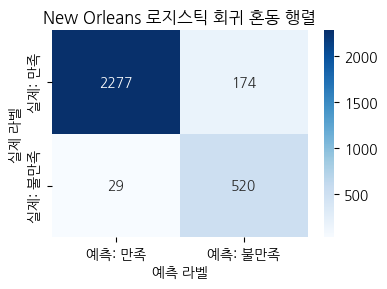


[New Orleans] CatBoost 모델 성능 평가
정확도    : 0.9453
F1 점수   : 0.8554
ROC-AUC  : 0.9831

[정밀도와 재현율]
              precision    recall  f1-score   support

       만족(0)       0.97      0.96      0.97      2451
      불만족(1)       0.83      0.88      0.86       549

    accuracy                           0.95      3000
   macro avg       0.90      0.92      0.91      3000
weighted avg       0.95      0.95      0.95      3000



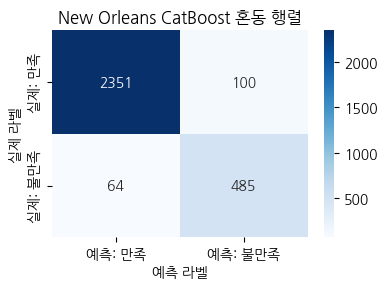


[New Orleans] PyTorch MLP 모델 성능 평가
정확도    : 0.9280
F1 점수   : 0.8305
ROC-AUC  : 0.9863

[정밀도와 재현율]
              precision    recall  f1-score   support

       만족(0)       0.99      0.92      0.95      2451
      불만족(1)       0.73      0.96      0.83       549

    accuracy                           0.93      3000
   macro avg       0.86      0.94      0.89      3000
weighted avg       0.94      0.93      0.93      3000



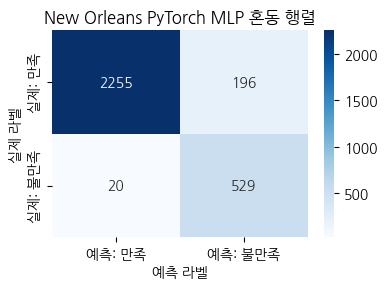

In [36]:
# 뉴올리언스 데이터로 세 가지 모델을 학습하고 평가한다.
# 예측 확률과 CatBoost 모델 객체는 비교 시각화와 SHAP 분석을 위해 딕셔너리에 보관한다.

city = "New Orleans"
X_train, X_test, y_train, y_test = city_datasets[city]

# 로지스틱 회귀
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]
evaluate_model(y_test, lr_preds, lr_proba, "로지스틱 회귀", city)
global_results[city]['lr_proba'] = lr_proba

# CatBoost
count_satisfied = sum(y_train == 0)
count_dissatisfied = sum(y_train == 1)

X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)
cb_model = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6,
                              scale_pos_weight=(count_satisfied / count_dissatisfied),
                              eval_metric='AUC', random_seed=42, verbose=0)
cb_model.fit(X_fit, y_fit, eval_set=(X_val, y_val), early_stopping_rounds=50)
cb_preds = cb_model.predict(X_test)
cb_proba = cb_model.predict_proba(X_test)[:, 1]
evaluate_model(y_test, cb_preds, cb_proba, "CatBoost", city)
global_results[city]['cb_model'] = cb_model
global_results[city]['cb_proba'] = cb_proba

# PyTorch MLP
train_and_evaluate_dl(city, X_train, X_test, y_train, y_test, epochs=30)



[Philly] 로지스틱 회귀 모델 성능 평가
정확도    : 0.9327
F1 점수   : 0.8543
ROC-AUC  : 0.9837

[정밀도와 재현율]
              precision    recall  f1-score   support

       만족(0)       0.99      0.93      0.96      2376
      불만족(1)       0.78      0.95      0.85       624

    accuracy                           0.93      3000
   macro avg       0.88      0.94      0.91      3000
weighted avg       0.94      0.93      0.94      3000



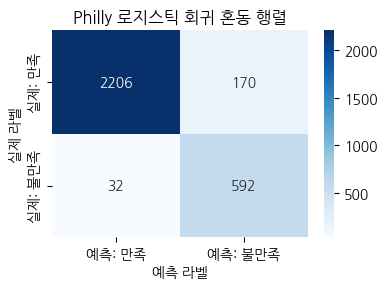


[Philly] CatBoost 모델 성능 평가
정확도    : 0.9377
F1 점수   : 0.8593
ROC-AUC  : 0.9827

[정밀도와 재현율]
              precision    recall  f1-score   support

       만족(0)       0.98      0.94      0.96      2376
      불만족(1)       0.81      0.92      0.86       624

    accuracy                           0.94      3000
   macro avg       0.89      0.93      0.91      3000
weighted avg       0.94      0.94      0.94      3000



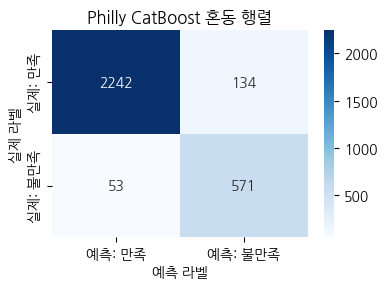


[Philly] PyTorch MLP 모델 성능 평가
정확도    : 0.9220
F1 점수   : 0.8368
ROC-AUC  : 0.9847

[정밀도와 재현율]
              precision    recall  f1-score   support

       만족(0)       0.99      0.91      0.95      2376
      불만족(1)       0.74      0.96      0.84       624

    accuracy                           0.92      3000
   macro avg       0.86      0.94      0.89      3000
weighted avg       0.94      0.92      0.93      3000



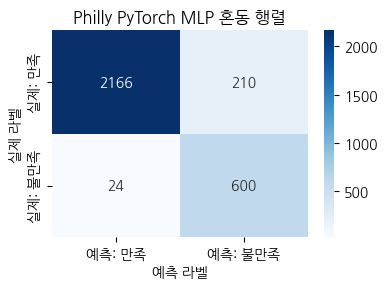

In [37]:
# 필라델피아 지역

city = "Philly"
X_train, X_test, y_train, y_test = city_datasets[city]

# 로지스틱 회귀
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]
evaluate_model(y_test, lr_preds, lr_proba, "로지스틱 회귀", city)
global_results[city]['lr_proba'] = lr_proba

# CatBoost
count_satisfied = sum(y_train == 0)
count_dissatisfied = sum(y_train == 1)

X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)
cb_model = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6,
                              scale_pos_weight=(count_satisfied / count_dissatisfied),
                              eval_metric='AUC', random_seed=42, verbose=0)
cb_model.fit(X_fit, y_fit, eval_set=(X_val, y_val), early_stopping_rounds=50)
cb_preds = cb_model.predict(X_test)
cb_proba = cb_model.predict_proba(X_test)[:, 1]
evaluate_model(y_test, cb_preds, cb_proba, "CatBoost", city)
global_results[city]['cb_model'] = cb_model
global_results[city]['cb_proba'] = cb_proba

# PyTorch MLP
train_and_evaluate_dl(city, X_train, X_test, y_train, y_test, epochs=30)



[Tucson] 로지스틱 회귀 모델 성능 평가
정확도    : 0.9433
F1 점수   : 0.8952
ROC-AUC  : 0.9876

[정밀도와 재현율]
              precision    recall  f1-score   support

       만족(0)       0.98      0.94      0.96      2234
      불만족(1)       0.85      0.95      0.90       766

    accuracy                           0.94      3000
   macro avg       0.91      0.94      0.93      3000
weighted avg       0.95      0.94      0.94      3000



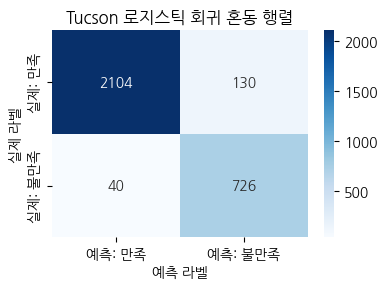


[Tucson] CatBoost 모델 성능 평가
정확도    : 0.9413
F1 점수   : 0.8893
ROC-AUC  : 0.9862

[정밀도와 재현율]
              precision    recall  f1-score   support

       만족(0)       0.97      0.95      0.96      2234
      불만족(1)       0.86      0.92      0.89       766

    accuracy                           0.94      3000
   macro avg       0.92      0.94      0.92      3000
weighted avg       0.94      0.94      0.94      3000



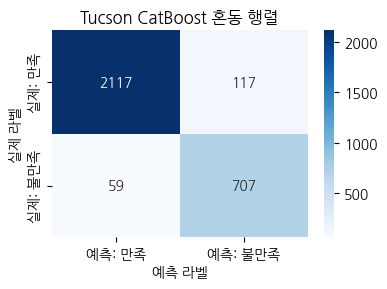


[Tucson] PyTorch MLP 모델 성능 평가
정확도    : 0.9460
F1 점수   : 0.8988
ROC-AUC  : 0.9871

[정밀도와 재현율]
              precision    recall  f1-score   support

       만족(0)       0.98      0.95      0.96      2234
      불만족(1)       0.86      0.94      0.90       766

    accuracy                           0.95      3000
   macro avg       0.92      0.94      0.93      3000
weighted avg       0.95      0.95      0.95      3000



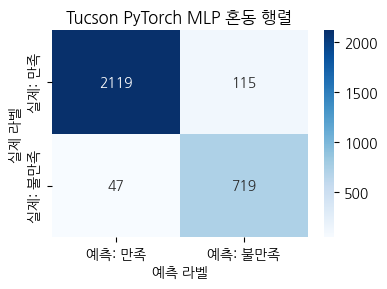

In [38]:
# 투손 지역

city = "Tucson"
X_train, X_test, y_train, y_test = city_datasets[city]

# 로지스틱 회귀
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]
evaluate_model(y_test, lr_preds, lr_proba, "로지스틱 회귀", city)
global_results[city]['lr_proba'] = lr_proba

# CatBoost
count_satisfied = sum(y_train == 0)
count_dissatisfied = sum(y_train == 1)

X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)
cb_model = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6,
                              scale_pos_weight=(count_satisfied / count_dissatisfied),
                              eval_metric='AUC', random_seed=42, verbose=0)
cb_model.fit(X_fit, y_fit, eval_set=(X_val, y_val), early_stopping_rounds=50)
cb_preds = cb_model.predict(X_test)
cb_proba = cb_model.predict_proba(X_test)[:, 1]
evaluate_model(y_test, cb_preds, cb_proba, "CatBoost", city)
global_results[city]['cb_model'] = cb_model
global_results[city]['cb_proba'] = cb_proba

# PyTorch MLP
train_and_evaluate_dl(city, X_train, X_test, y_train, y_test, epochs=30)


## 5. 결과 시각화 및 해석

도시별 ROC 곡선, SHAP 그래프, 성능표와 오류 분석 결과를 화면에 표시한다.


### New Orleans

ROC 곡선은 세 모델의 전반적인 분류 성능을 비교한다. SHAP 그래프에서는 어떤 PCA 피처가 예측에 크게 작용했는지와, 해당 피처 값의 변화가 예측 방향에 미친 영향을 함께 확인한다.


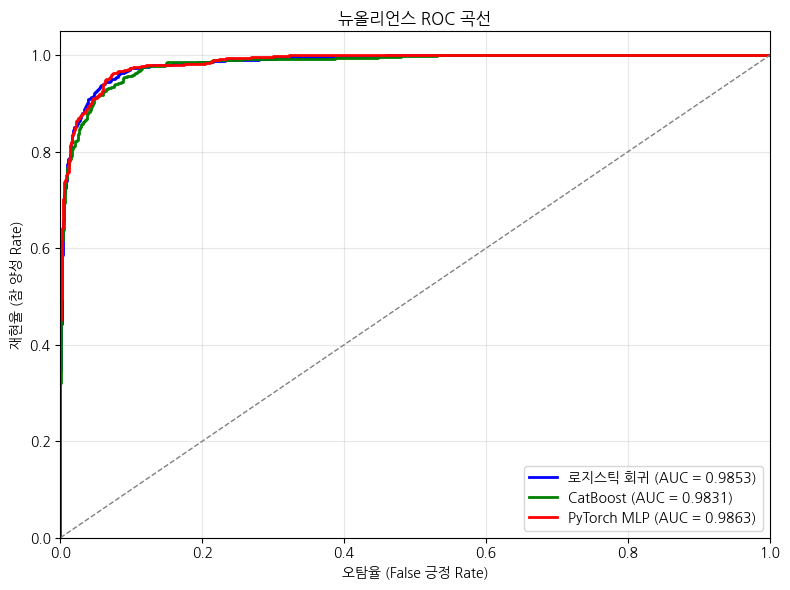

/tmp/ipykernel_26391/2395252557.py:34: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)


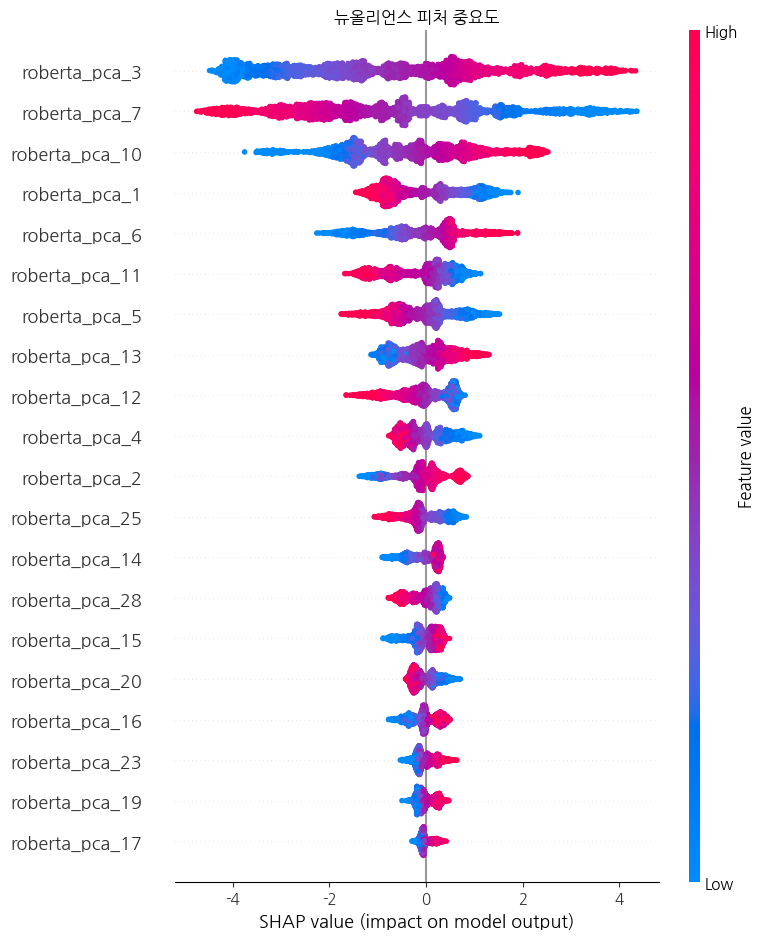

<Figure size 800x500 with 0 Axes>

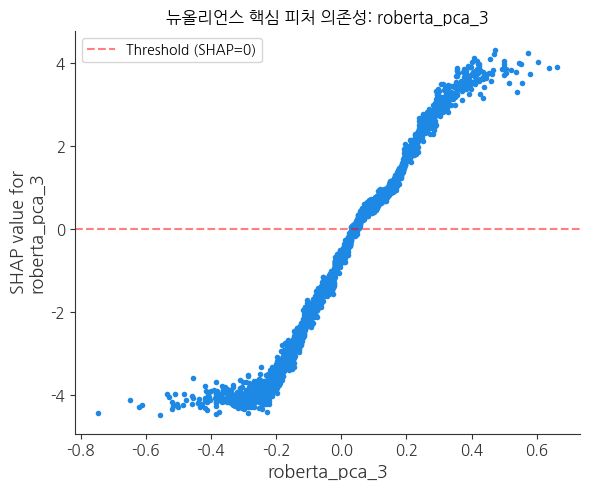

In [39]:
# 예측 결과와 모델 객체를 바탕으로 뉴올리언스의 ROC와 SHAP 그래프를 그린다.

city = "New Orleans"
X_train, X_test, y_train, y_test = city_datasets[city]
lr_probs = global_results[city]['lr_proba']
cb_probs = global_results[city]['cb_proba']
dl_probs = global_results[city]['dl_proba']
cb_model = global_results[city]['cb_model']

# 다중 모델 ROC 곡선
plt.figure(figsize=(8, 6))
for name, probs, color in [("로지스틱 회귀", lr_probs, 'blue'),
                           ("CatBoost", cb_probs, 'green'),
                           ("PyTorch MLP", dl_probs, 'red')]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc(fpr, tpr):.4f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('오탐율 (False 긍정 Rate)')
plt.ylabel('재현율 (참 양성 Rate)')
plt.title('뉴올리언스 ROC 곡선')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

explainer = shap.TreeExplainer(cb_model)
shap_values = explainer.shap_values(X_test)

# SHAP 요약 그래프
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("뉴올리언스 피처 중요도")
plt.tight_layout()
plt.show()

# SHAP 의존성 그래프
top_feature_idx = np.argmax(np.abs(shap_values).mean(axis=0))
top_feature_name = X_test.columns[top_feature_idx]

plt.figure(figsize=(8, 5))
shap.dependence_plot(top_feature_idx, shap_values, X_test, interaction_index=None, show=False)
plt.axhline(0, color='red', linestyle='--', alpha=0.5, label='Threshold (SHAP=0)')
plt.title(f"뉴올리언스 핵심 피처 의존성: {top_feature_name}")
plt.legend()
plt.tight_layout()
plt.show()

### Philadelphia

ROC 곡선이 왼쪽 위에 가까울수록 분류력이 좋다. SHAP 결과는 중요도가 높은 피처와 예측 방향을 보여 주며, 인과관계보다는 모델이 활용한 패턴으로 해석하는 것이 적절하다.


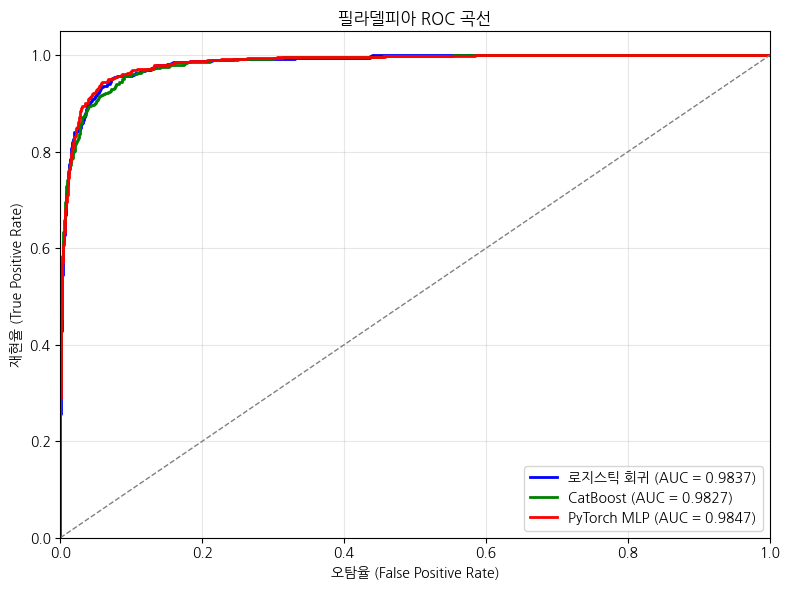

/tmp/ipykernel_26391/456984659.py:34: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)


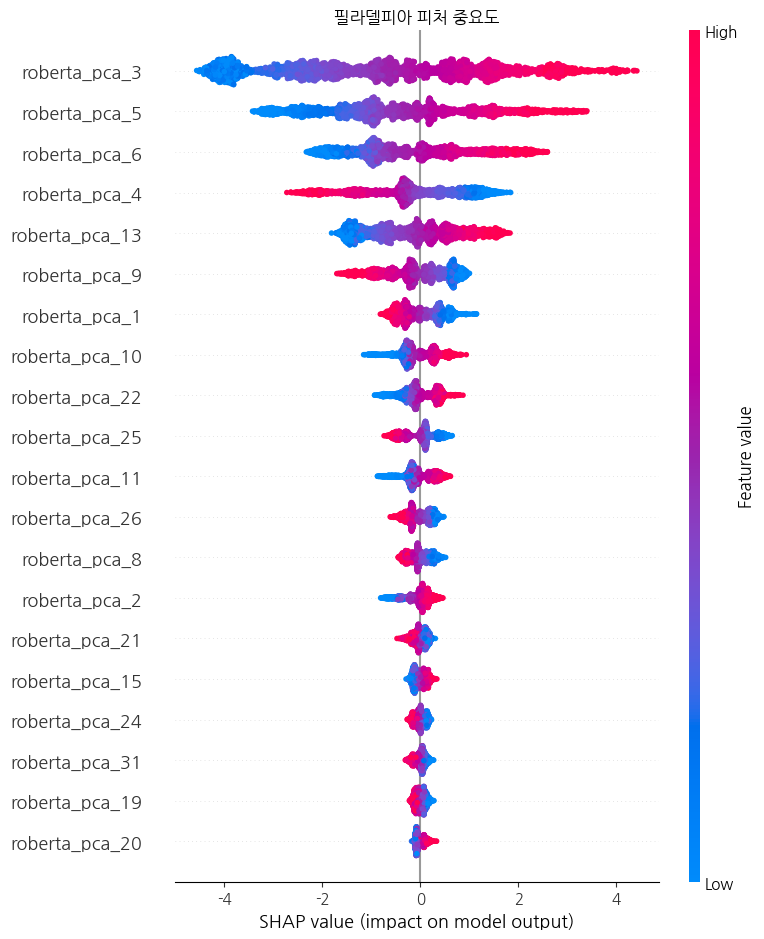

<Figure size 800x500 with 0 Axes>

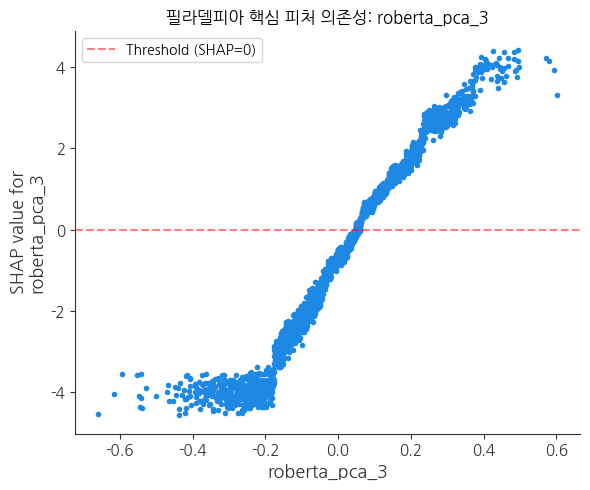

In [40]:
# 필라델피아

city = "Philly"
X_train, X_test, y_train, y_test = city_datasets[city]
lr_probs = global_results[city]['lr_proba']
cb_probs = global_results[city]['cb_proba']
dl_probs = global_results[city]['dl_proba']
cb_model = global_results[city]['cb_model']

# 다중 모델 ROC 곡선
plt.figure(figsize=(8, 6))
for name, probs, color in [("로지스틱 회귀", lr_probs, 'blue'),
                           ("CatBoost", cb_probs, 'green'),
                           ("PyTorch MLP", dl_probs, 'red')]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc(fpr, tpr):.4f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('오탐율 (False Positive Rate)')
plt.ylabel('재현율 (True Positive Rate)')
plt.title('필라델피아 ROC 곡선')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

explainer = shap.TreeExplainer(cb_model)
shap_values = explainer.shap_values(X_test)

# SHAP 요약 그래프
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("필라델피아 피처 중요도")
plt.tight_layout()
plt.show()

# SHAP 의존성 그래프
top_feature_idx = np.argmax(np.abs(shap_values).mean(axis=0))
top_feature_name = X_test.columns[top_feature_idx]

plt.figure(figsize=(8, 5))
shap.dependence_plot(top_feature_idx, shap_values, X_test, interaction_index=None, show=False)
plt.axhline(0, color='red', linestyle='--', alpha=0.5, label='Threshold (SHAP=0)')
plt.title(f"필라델피아 핵심 피처 의존성: {top_feature_name}")
plt.legend()
plt.tight_layout()
plt.show()


### Tucson

도시별 데이터 특성이 다를 수 있으므로 다른 도시와 절대 성능만 비교하기보다 세 모델의 상대적인 차이를 본다. SHAP 의존성 그래프에서는 핵심 피처의 값에 따라 예측 기여도가 어떻게 변하는지 확인한다.


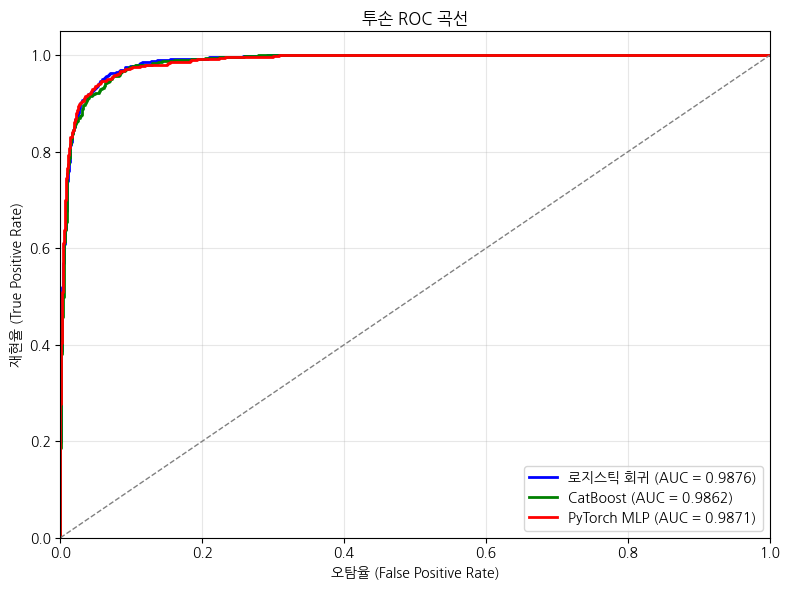

/tmp/ipykernel_26391/3132605964.py:34: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)


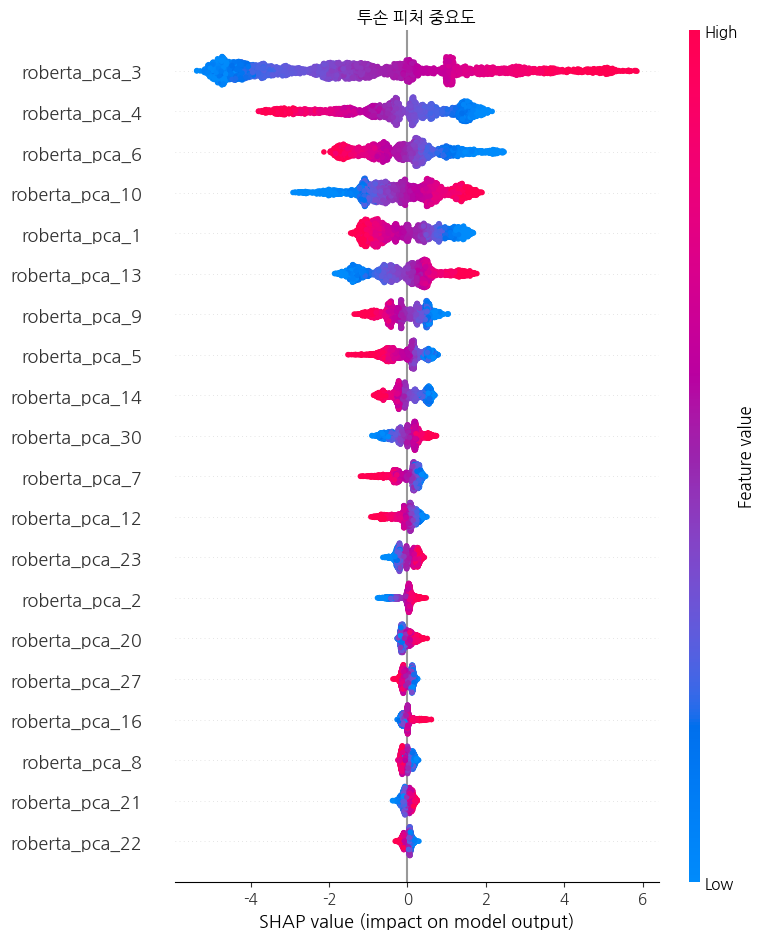

<Figure size 800x500 with 0 Axes>

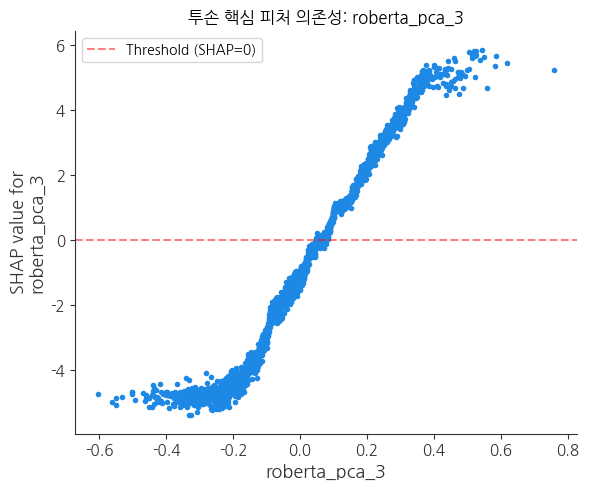

In [41]:
# 투손

city = "Tucson"
X_train, X_test, y_train, y_test = city_datasets[city]
lr_probs = global_results[city]['lr_proba']
cb_probs = global_results[city]['cb_proba']
dl_probs = global_results[city]['dl_proba']
cb_model = global_results[city]['cb_model']

# 다중 모델 ROC 곡선
plt.figure(figsize=(8, 6))
for name, probs, color in [("로지스틱 회귀", lr_probs, 'blue'),
                           ("CatBoost", cb_probs, 'green'),
                           ("PyTorch MLP", dl_probs, 'red')]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc(fpr, tpr):.4f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('오탐율 (False Positive Rate)')
plt.ylabel('재현율 (True Positive Rate)')
plt.title('투손 ROC 곡선')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

explainer = shap.TreeExplainer(cb_model)
shap_values = explainer.shap_values(X_test)

# SHAP 요약 그래프
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("투손 피처 중요도")
plt.tight_layout()
plt.show()

# SHAP 의존성 그래프
top_feature_idx = np.argmax(np.abs(shap_values).mean(axis=0))
top_feature_name = X_test.columns[top_feature_idx]

plt.figure(figsize=(8, 5))
shap.dependence_plot(top_feature_idx, shap_values, X_test, interaction_index=None, show=False)
plt.axhline(0, color='red', linestyle='--', alpha=0.5, label='Threshold (SHAP=0)')
plt.title(f"투손 핵심 피처 의존성: {top_feature_name}")
plt.legend()
plt.tight_layout()
plt.show()

### 도시별 모델 성능 비교

F1 점수는 불만족 리뷰를 얼마나 균형 있게 찾아내는지, ROC-AUC는 임계값 전반의 구분 능력을 보여 준다. 두 지표가 함께 높은 모델을 우선적으로 살펴본다.


,City,Model,F1 점수,ROC-AUC
0,New Orleans,로지스틱 회귀,0.836685,0.985327
1,New Orleans,CatBoost,0.855379,0.983082
2,New Orleans,PyTorch MLP,0.830455,0.986284
3,Philly,로지스틱 회귀,0.854257,0.983735
4,Philly,CatBoost,0.859293,0.982745
5,Philly,PyTorch MLP,0.836820,0.984708
6,Tucson,로지스틱 회귀,0.895191,0.987598
7,Tucson,CatBoost,0.889308,0.986196
8,Tucson,PyTorch MLP,0.898750,0.987132


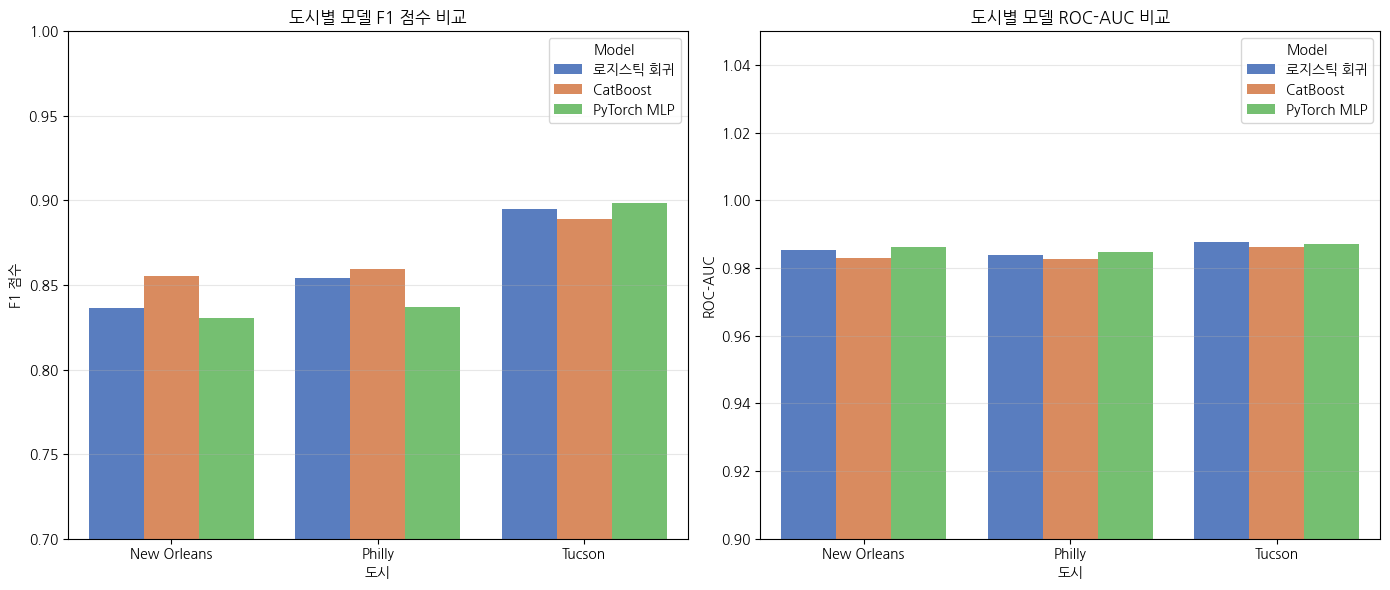

In [42]:
# 세 도시와 세 모델의 F1 점수와 ROC-AUC를 하나의 그래프로 비교한다.
# 런타임에 보관한 예측 확률로 지표를 다시 계산해 막대그래프로 나타낸다.

data_rows = []

for city in city_datasets.keys():
    _, _, _, y_test = city_datasets[city]

    lr_proba = global_results[city]['lr_proba']
    cb_proba = global_results[city]['cb_proba']
    dl_probs = global_results[city]['dl_proba']

    lr_pred = (lr_proba >= 0.5).astype(int)
    cb_pred = (cb_proba >= 0.5).astype(int)
    dl_pred = (dl_probs >= 0.5).astype(int)

    for model_name, preds, probas in [("로지스틱 회귀", lr_pred, lr_proba),
                                      ("CatBoost", cb_pred, cb_proba),
                                      ("PyTorch MLP", dl_pred, dl_probs)]:
        f1 = f1_score(y_test, preds)
        auc_val = roc_auc_score(y_test, probas)
        data_rows.append({"City": city, "Model": model_name, "F1 점수": f1, "ROC-AUC": auc_val})

df_metrics = pd.DataFrame(data_rows)
display(df_metrics)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x="City", y="F1 점수", hue="Model", data=df_metrics, ax=axes[0], palette="muted")
axes[0].set_title("도시별 모델 F1 점수 비교")
axes[0].set_ylim(0.7, 1.0)
axes[0].set_xlabel("도시")
axes[0].grid(axis='y', alpha=0.3)

sns.barplot(x="City", y="ROC-AUC", hue="Model", data=df_metrics, ax=axes[1], palette="muted")
axes[1].set_title("도시별 모델 ROC-AUC 비교")
axes[1].set_ylim(0.9, 1.05)
axes[1].set_xlabel("도시")
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 오류 분석

정확히 찾은 불만족 리뷰와 놓친 불만족 리뷰의 SHAP 기여도를 비교한다. 두 집단의 차이가 큰 피처는 모델이 혼동하는 리뷰 유형을 이해하는 단서가 된다.


,Feature,재현율 (TP),오탐율 (FN)
6,roberta_pca_7,1.867456,1.448270
2,roberta_pca_3,1.656615,1.709482
9,roberta_pca_10,1.221327,1.283799
0,roberta_pca_1,0.736697,0.774134
5,roberta_pca_6,0.676539,0.661395
4,roberta_pca_5,0.605659,0.523353
12,roberta_pca_13,0.464313,0.400299
10,roberta_pca_11,0.458895,0.515614
11,roberta_pca_12,0.386883,0.368523
1,roberta_pca_2,0.362627,0.412970


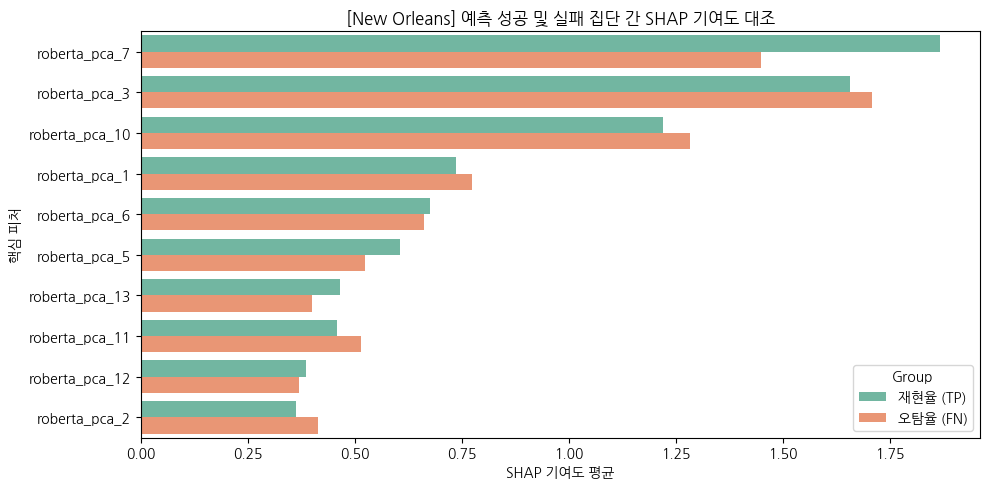

,Feature,재현율 (TP),오탐율 (FN)
2,roberta_pca_3,1.745309,1.659988
4,roberta_pca_5,1.459526,1.240594
5,roberta_pca_6,0.999277,0.991140
3,roberta_pca_4,0.788007,0.741163
12,roberta_pca_13,0.729847,0.800039
8,roberta_pca_9,0.566670,0.530311
9,roberta_pca_10,0.365345,0.309469
0,roberta_pca_1,0.361701,0.400699
24,roberta_pca_25,0.289693,0.293081
21,roberta_pca_22,0.281301,0.284001


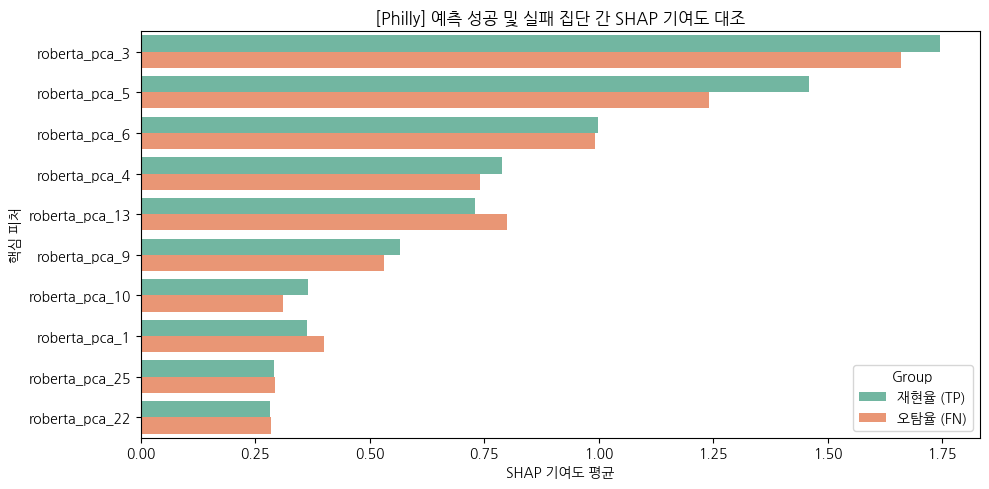

,Feature,재현율 (TP),오탐율 (FN)
2,roberta_pca_3,2.388691,1.873591
3,roberta_pca_4,1.241577,1.139076
9,roberta_pca_10,0.880150,0.842805
5,roberta_pca_6,0.775137,0.774136
0,roberta_pca_1,0.743254,0.831608
12,roberta_pca_13,0.558261,0.645127
8,roberta_pca_9,0.432200,0.433199
4,roberta_pca_5,0.392862,0.357900
13,roberta_pca_14,0.316827,0.323806
29,roberta_pca_30,0.267882,0.314919


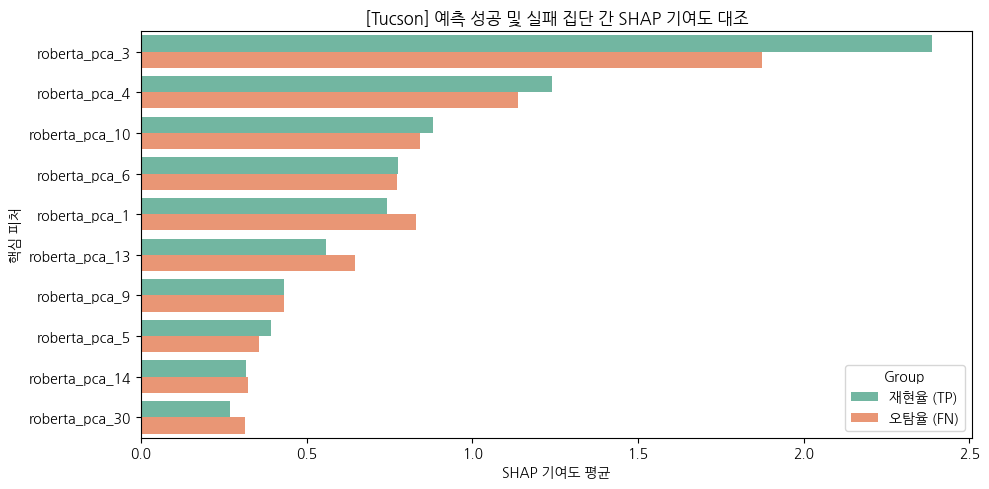

In [43]:
# 모델이 예측에 실패한 원인을 살펴보기 위해 도시별 오류 분석을 수행한다.
# 참 양성과 거짓 음성의 SHAP 값을 비교해 모델이 혼동한 요인을 추적한다.

for city in city_datasets.keys():
    X_train, X_test, y_train, y_test = city_datasets[city]
    cb_model = global_results[city]['cb_model']
    cb_preds = cb_model.predict(X_test)

    explainer = shap.TreeExplainer(cb_model)
    shap_values = explainer.shap_values(X_test)

    tp_idx = np.where((y_test == 1) & (cb_preds == 1))[0]
    fn_idx = np.where((y_test == 1) & (cb_preds == 0))[0]

    if len(fn_idx) > 0:
        tp_shap_mean = np.abs(shap_values[tp_idx]).mean(axis=0)
        fn_shap_mean = np.abs(shap_values[fn_idx]).mean(axis=0)

        df_error = pd.DataFrame({
            'Feature': X_test.columns,
            '재현율 (TP)': tp_shap_mean,
            '오탐율 (FN)': fn_shap_mean
        }).sort_values(by='재현율 (TP)', ascending=False).head(10)


        display(df_error)
        df_error_melt = df_error.melt(id_vars='Feature', var_name='Group', value_name='Mean SHAP')

        plt.figure(figsize=(10, 5))
        sns.barplot(x='Mean SHAP', y='Feature', hue='Group', data=df_error_melt, palette='Set2')
        plt.title(f"[{city}] 예측 성공 및 실패 집단 간 SHAP 기여도 대조")
        plt.xlabel("SHAP 기여도 평균")
        plt.ylabel("핵심 피처")
        plt.tight_layout()
        plt.show()

### PCA 차원 의미 살펴보기

PCA 값이 높은 리뷰와 낮은 리뷰에서 자주 등장하는 단어를 비교한다. PCA 축은 여러 표현이 섞인 잠재 차원이므로, 단어 몇 개만으로 감정이나 주제를 단정하지 않고 보조 해석으로 사용한다.


In [44]:
# 특정 PCA Component의 고정값(높은 값/낮은 값)에 매핑되는 원본 텍스트를 추출하여 해당 차원의 언어학적/문맥적 의미를 해석하기 위한 역추적 분석 함수이다.

def analyze_pca_meaning(city_name, pca_feature_name, top_n=5):
    urls = data_sources[city_name]
    df_raw = read_csv_with_fallback(urls["raw_path"], urls["raw_url"])
    df_pca = read_csv_with_fallback(urls["pca_path"], urls["pca_url"])

    text_col = 'text' if 'text' in df_raw.columns else df_raw.select_dtypes(include=[object]).columns[0]

    df_analysis = pd.DataFrame({
        'text': df_raw[text_col],
        'pca_value': df_pca[pca_feature_name]
    })

    top_reviews = df_analysis.sort_values(by='pca_value', ascending=False).head(top_n)
    bottom_reviews = df_analysis.sort_values(by='pca_value', ascending=True).head(top_n)

    print(f"[{city_name}] {pca_feature_name} 차원 해석")

    print(f"\n  [높은 값]")
    for row in top_reviews.itertuples():
        print(f"  ({row.pca_value:.4f}) {row.text[:120]}...")

    print(f"\n  [낮은 값]")
    for row in bottom_reviews.itertuples():
        print(f"  ({row.pca_value:.4f}) {row.text[:120]}...")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    vectorizer = CountVectorizer(stop_words='english', max_features=10)

    try:
        X_top = vectorizer.fit_transform(top_reviews['text'])
        top_words = pd.DataFrame(X_top.toarray(), columns=vectorizer.get_feature_names_out()).sum().sort_values(ascending=False)
        sns.barplot(x=top_words.values, y=top_words.index, ax=axes[0], palette='bone')
        axes[0].set_title(f"{pca_feature_name} (High)")
        axes[0].set_xlabel("빈도")
    except Exception:
        axes[0].text(0.5, 0.5, '데이터 부족', ha='center')

    try:
        X_bottom = vectorizer.fit_transform(bottom_reviews['text'])
        bottom_words = pd.DataFrame(X_bottom.toarray(), columns=vectorizer.get_feature_names_out()).sum().sort_values(ascending=False)
        sns.barplot(x=bottom_words.values, y=bottom_words.index, ax=axes[1], palette='bone')
        axes[1].set_title(f"{pca_feature_name} (Low)")
        axes[1].set_xlabel("빈도")
    except Exception:
        axes[1].text(0.5, 0.5, '데이터 부족', ha='center')

    plt.tight_layout()
    plt.show()

로컬 CSV 불러오기: /content/Team-6/data/processed/yelp_subset_new_orleans_15k_features.csv
로컬 CSV 불러오기: /content/Team-6/data/embeddings/new_orleans_pca_32.csv
[New Orleans] roberta_pca_3 차원 해석

  [높은 값]
  (0.6626) 0 if I could 
Couldn't order my meal before arriving cause they wouldn't answer. Came to store to order & wouldn't open ...
  (0.6513) Really awful.  Just waited here for more than 20 min and the place is not even full.  The service was non existent.  Jus...
  (0.6384) Omg...homeless dudes passed.out or maybe dead in the first booth.  I just wanted a large iced coffee.  The girl behind t...

  [낮은 값]
  (-0.7473) I have been wanting Shrimp and Grits from this restaurant ever since I saw a picture floating on Instagram! This place d...
  (-0.6480) I absolutely LOVE Max Well!!! Mardi Gras food got me all heavy feeling, so naturally, I was craving a big salad Max Well...
  (-0.6382) My husband and I truly enjoyed this delicious meal last night! The salmon appetizer and spicy chicken no

/tmp/ipykernel_26391/1898849916.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_words.values, y=top_words.index, ax=axes[0], palette='bone')
/tmp/ipykernel_26391/1898849916.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom_words.values, y=bottom_words.index, ax=axes[1], palette='bone')


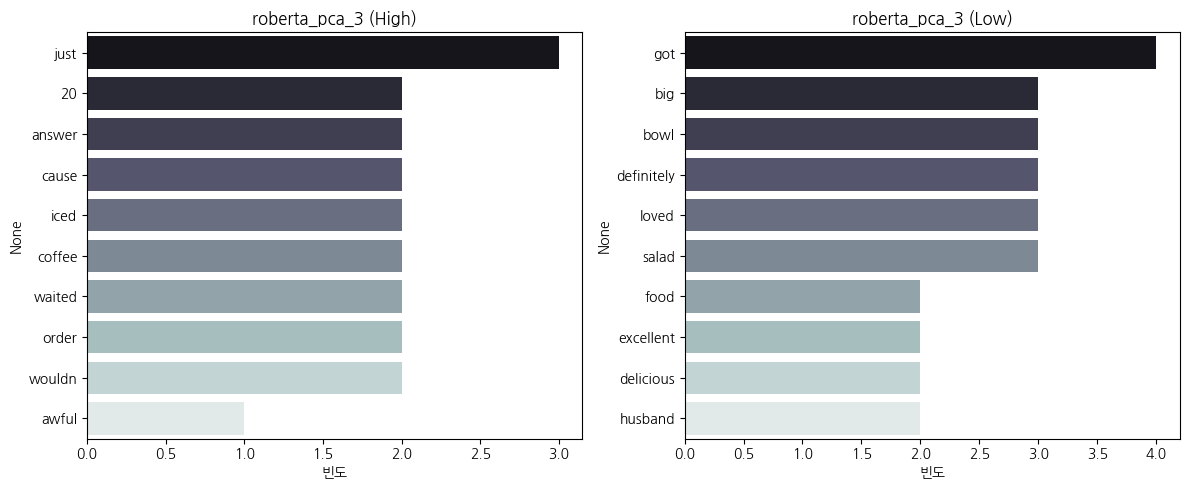

로컬 CSV 불러오기: /content/Team-6/data/processed/yelp_subset_philly_15k_features.csv
로컬 CSV 불러오기: /content/Team-6/data/embeddings/philly_pca_32.csv
[Philly] roberta_pca_3 차원 해석

  [높은 값]
  (0.7041) they need to train their employees the correct way ...worst service ever ....they are dispicable !! if the phone number ...
  (0.6804) About a week ago , I went there to pick up an order . It was around 9:30 pm . The bouncer asked me if I was there to pic...
  (0.6706) I have had 2 racist encounters within a 3 month span .i am a you g African American woman . This is the closet market.  ...

  [낮은 값]
  (-0.6783) Restaurant is clean, staff are pleasant and food is excellent! I came alone the first time and had a wrap with authentic...
  (-0.6605) My wife and I tried this place out for the first time and we really enjoyed it! The environment inside is cozy and comfo...
  (-0.6322) The decor looks great! And even though I'm vegan, I've eaten here a number of times and the chefs have created deliciou

/tmp/ipykernel_26391/1898849916.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_words.values, y=top_words.index, ax=axes[0], palette='bone')
/tmp/ipykernel_26391/1898849916.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom_words.values, y=bottom_words.index, ax=axes[1], palette='bone')


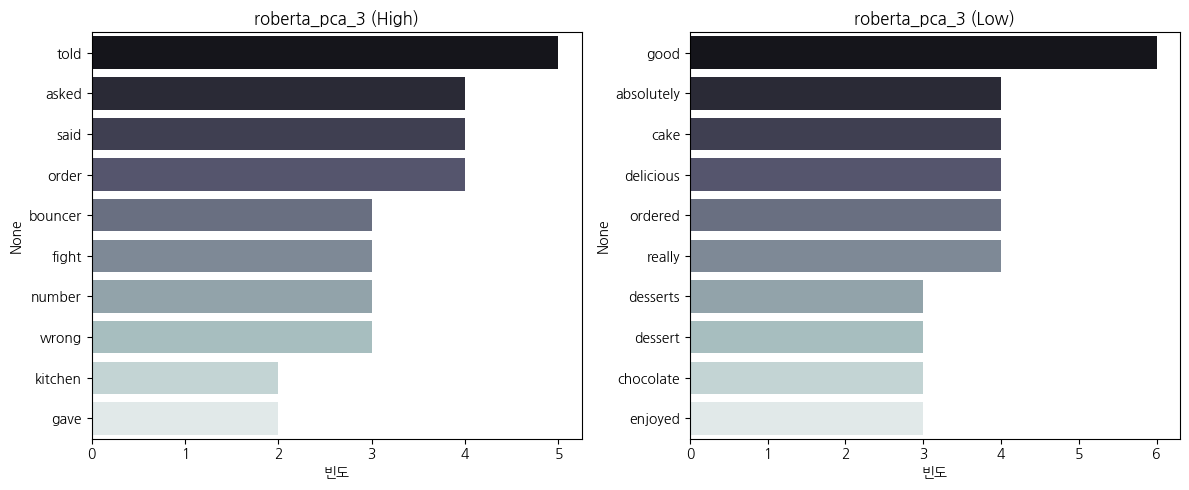

로컬 CSV 불러오기: /content/Team-6/data/processed/yelp_subset_tucson_15k_features.csv
로컬 CSV 불러오기: /content/Team-6/data/embeddings/tucson_pca_32.csv
[Tucson] roberta_pca_3 차원 해석

  [높은 값]
  (0.7595) I recently  visited the Denny's  on 22nd & Alvernon for lunch l Will not go back to this location
Service was poor . Aft...
  (0.7514) after i went into the place they had the new computer up and running i like it nice but only wanted a cup of coffee i de...
  (0.6876) Rude manager Andrew , bad customer service , this place was never really clean now that I'm  speaking of the negatives, ...

  [낮은 값]
  (-0.7341) Tried this truck today at my place of employment! I had the 3 tacos special, 1 chicken, 1 carne Asada, and 1 carnitas!
A...
  (-0.6150) This is my first time going to this restaurant, and let me tell you that it was excellent! Service is superb! The food i...
  (-0.6104) This is now our favorite new restaurant! Loved everything we ordered! They cook with a lot of fresh herbs and that make

/tmp/ipykernel_26391/1898849916.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_words.values, y=top_words.index, ax=axes[0], palette='bone')
/tmp/ipykernel_26391/1898849916.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom_words.values, y=bottom_words.index, ax=axes[1], palette='bone')


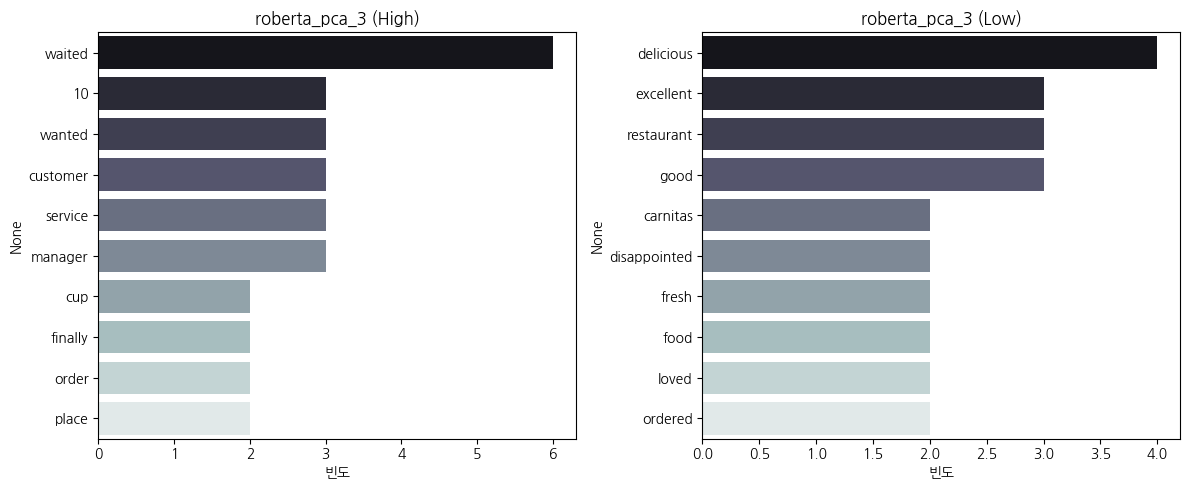

In [45]:
for city_name in ["New Orleans", "Philly", "Tucson"]:
    analyze_pca_meaning(
        city_name=city_name,
        pca_feature_name="roberta_pca_3",
        top_n=3,
    )
